# Reproductions of Juno result

Step-by-step reproduction of Figures 2 and 4 (all physics, constants, and the needed covariance data are embedded). Only `numpy` and `matplotlib` are required dependencies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, LogFormatterMathtext

if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz

# Set the values of constants
G_SI = 6.67430e-11
C_KM_S = 299_792.458
C_M_S = C_KM_S * 1.0e3
HBAR_EV_S = 6.582_119_569e-16

MU_KM = 1.266_865_341e8          # GM for Jupiter in units of km^3/s^2
MU_M = MU_KM * 1.0e9
M_JUP_KG = MU_M / G_SI
R_J_KM = 71_492.0
R_J_M = R_J_KM * 1.0e3

# Orbital parameters of Juno estimated from perijove 1 through perijove 17
T_ORBIT_S = 53.5 * 86_400.0
A_KM = (MU_KM * T_ORBIT_S**2 / (4.0 * np.pi**2)) ** (1.0 / 3.0)
A_M = A_KM * 1.0e3
ECC = 1.0 - 1.06 * R_J_KM / A_KM
INC, OMEGA = 1.57, 3.08
N_MAX = 10

print(f"a = {A_KM:.4e} km ({A_KM/R_J_KM:.1f} R_J), e = {ECC:.5f}, 1-e = {1-ECC:.5f}")

a = 4.0929e+06 km (57.3 R_J), e = 0.98148, 1-e = 0.01852


## Gravity precession derivatives (Appendix B + GR term)

`d<dw_g>/dJ_l` for `l=2..10` (linear-in-`J_l` coefficients of eqs. B.1-B.9) plus the GR `d/dmu` term.

In [2]:
def _trig(inc, omega):
    return dict(
        cos_i=np.cos(inc), sin_i=np.sin(inc), csc_i=1.0/np.sin(inc),
        cos3i=np.cos(3*inc), cos5i=np.cos(5*inc),
        cos2i=np.cos(2*inc), cos4i=np.cos(4*inc), cos6i=np.cos(6*inc),
        cos8i=np.cos(8*inc), cos10i=np.cos(10*inc),
        sin2i=np.sin(2*inc), sin3i=np.sin(3*inc), sin4i=np.sin(4*inc), sin5i=np.sin(5*inc),
        sin_w=np.sin(omega), sin3w=np.sin(3*omega), sin5w=np.sin(5*omega), sin7w=np.sin(7*omega),
        cos2w=np.cos(2*omega), cos4w=np.cos(4*omega), cos6w=np.cos(6*omega), cos8w=np.cos(8*omega),
    )

def domega_dJl(l, a, e, inc, omega, RJ):
    """Coefficient of J_l in eqs. B.1-B.9 = d<dw_g>/dJ_l (unnormalised)."""
    e2, e4, e6, e8 = e**2, e**4, e**6, e**8
    em1 = e**2 - 1.0
    t = _trig(inc, omega); pi = np.pi
    cos_i, sin_i, csc_i = t["cos_i"], t["sin_i"], t["csc_i"]
    cos3i, cos5i = t["cos3i"], t["cos5i"]
    cos2i, cos4i, cos6i, cos8i, cos10i = t["cos2i"], t["cos4i"], t["cos6i"], t["cos8i"], t["cos10i"]
    sin2i, sin3i, sin4i, sin5i = t["sin2i"], t["sin3i"], t["sin4i"], t["sin5i"]
    sin_w, sin3w, sin5w, sin7w = t["sin_w"], t["sin3w"], t["sin5w"], t["sin7w"]
    cos2w, cos4w, cos6w, cos8w = t["cos2w"], t["cos4w"], t["cos6w"], t["cos8w"]

    if l == 2:
        return 3*pi*(3+5*cos2i)*RJ**2/(4*a**2*em1**2)
    if l == 3:
        return (3*pi*(-1-3*e2-4*cos2i+5*(1+7*e2)*cos4i)*csc_i*sin_w*RJ**3/(32*a**3*e*em1**3))
    if l == 4:
        return (1.0/(512*a**4*em1**4))*15*pi*(
            -27*(4+5*e2) + 2*(-6+5*e2)*cos2w
            + 4*cos2i*(-52-63*e2+2*(-2+7*e2)*cos2w)
            + 7*cos4i*(-28-27*e2+2*(2+9*e2)*cos2w))*RJ**4
    if l == 5:
        return (1.0/(1024*a**5*e*em1**5))*15*pi*(
            (4+41*e2+18*e4)*(2*sin_i+7*(sin3i+3*sin5i))*sin_w
            + 28*e2*(1+2*e2)*(7+9*cos2i)*sin_i**3*sin3w
            - e2*cos_i*((4+3*e2)*(2*cos_i+21*(cos3i+5*cos5i))*csc_i*sin_w
                        + 7*e2*(2*sin2i+15*sin4i)*sin3w))*RJ**5
    if l == 6:
        return (1.0/(32768*a**6*em1**6))*105*pi*(
            2256*cos4i + 2376*cos6i
            + 5*((472+1940*e2+675*e4)*cos2i + 3*e2*(2*(292+99*e2)*cos4i+11*(44+13*e2)*cos6i))
            - 5*(10*e2*(6+7*e2)+(-68+254*e2+195*e4)*cos2i+6*(-4+102*e2+55*e4)*cos4i
                 +33*(4+34*e2+13*e4)*cos6i)*cos2w
            + 50*(24+100*e2+35*e4+4*cos2w)
            - 6*e2*(-28+45*e2+4*(-4+33*e2)*cos2i+11*(4+13*e2)*cos4i)*cos4w*sin_i**2)*RJ**6
    if l == 7:
        return (1.0/(524288*a**7*e*em1**7))*21*pi*sin_i**3*(
            -5*(25*(8+148*e2+205*e4+35*e6)+(448+6592*e2+7240*e4+900*e6)*cos2i
                +12*(56-5*e2*(-76+41*e2+33*e4))*cos4i-132*(-16-80*e2+65*e4*(2+e2))*cos6i
                -429*(8+212*e2+365*e4+75*e6)*cos8i)*csc_i**4*sin_w
            + 30*e2*(14*(15+7*e2)*(-8+27*e2)+(-2280+13687*e2+6237*e4)*cos2i
                     +22*(24+967*e2+351*e4)*cos4i+143*(24+151*e2+45*e4)*cos6i)*csc_i**2*sin3w
            + 264*e4*(-45+77*e2+4*(-5+52*e2)*cos2i+65*(1+3*e2)*cos4i)*sin5w)*RJ**7
    if l == 8:
        return (1.0/(16777216*a**8*em1**8))*63*pi*(
            5*(-1225*(192+35*e2*(48+56*e2+9*e4))
               -280*(1664+7*e2*(2064+2400*e2+385*e4))*cos2i
               -308*(1472+7*e2*(1776+2040*e2+325*e4))*cos4i
               -3432*(128+7*e2*(144+160*e2+25*e4))*cos6i
               -715*(704+7*e2*(624+600*e2+85*e4))*cos8i)
            + 70*(35*(-96+208*e2+950*e4+225*e6)+16*(-384+1648*e2+5160*e4+1155*e6)*cos2i
                  +44*(-96+1360*e2+2870*e4+585*e6)*cos4i+2288*e2*(48+80*e2+15*e4)*cos6i
                  +143*(96+1328*e2+1610*e4+255*e6)*cos8i)*cos2w
            + 616*e2*(6*(-280+944*e2+363*e4)+(-1960+14128*e2+4797*e4)*cos2i
                      +26*(40+688*e2+195*e4)*cos4i+65*(40+208*e2+51*e4)*cos6i)*cos4w*sin_i**2
            + 4576*e4*(-22+39*e2+4*(-2+25*e2)*cos2i+5*(6+17*e2)*cos4i)*cos6w*sin_i**4)*RJ**8
    if l == 9:
        return (1.0/(67108864*a**9*e*em1**9))*45*pi*sin_i**5*(
            7*(98*(64+1968*e2+5768*e4+3325*e6+315*e8)
               +14*(960+25808*e2+67032*e4+33635*e6+2695*e8)*cos2i
               -88*(-192-3344*e2-3864*e4+1225*e6+455*e8)*cos4i
               -429*(-64+7*e2*(-80+232*e2+405*e4+65*e6))*cos6i
               -286*(-320+7*e2*(-528+488*e2+1465*e4+255*e6))*cos8i
               -2431*(64+2608*e2+9128*e4+6125*e6+665*e8)*cos10i)*csc_i**6*sin_w
            - 4312*e2*(21*(-80+372*e2+705*e4+121*e6)+28*(-96+712*e2+1178*e4+195*e6)*cos2i
                       +52*(-16+580*e2+773*e4+119*e6)*cos4i+52*(32+744*e2+834*e4+119*e6)*cos6i
                       +221*(16+156*e2+147*e4+19*e6)*cos8i)*csc_i**4*sin3w
            - 32032*e4*(22*(-12+43*e2+13*e4)+(-276+2213*e2+605*e4)*cos2i
                        +(200+2462*e2+578*e4)*cos4i+17*(20+91*e2+19*e4)*cos6i)*csc_i**2*sin5w
            - 4576*e6*(-91+165*e2+4*(-7+102*e2)*cos2i+17*(7+19*e2)*cos4i)*sin7w)*RJ**9
    if l == 10:
        return (1.0/(2147483648*a**10*em1**10))*495*pi*(
            7*(23814*(128+3*e2*(640+1568*e2+840*e4+77*e6))
               +294*(20608+307584*e2+751968*e4+402360*e6+36855*e8)*cos2i
               +312*(19072+279936*e2+679392*e4+362040*e6+33075*e8)*cos4i
               +1053*(5504+21*e2*(3712+8864*e2+4680*e4+425*e6))*cos6i
               +442*(12928+21*e2*(8064+18528*e2+9560*e4+855*e6))*cos8i
               +4199*(1664+3*e2*(5760+7*e2*(1632+760*e2+63*e4)))*cos10i)
            - 84*(294*(-192+544*e2+6020*e4+4802*e6+539*e8)
                  +98*(-1088+5344*e2+42028*e4+32158*e6+3549*e8)*cos2i
                  +104*(-832+10720*e2+55356*e4+39102*e6+4165*e8)*cos4i
                  +13*(-3648+156640*e2+626444*e4+411278*e6+42245*e8)*cos6i
                  +442*(64+7328*e2+24276*e4+14826*e6+1463*e8)*cos8i
                  +4199*(64+1312*e2+3220*e4+1666*e6+147*e8)*cos10i)*cos2w
            - 8736*e2*(33*(-224+1208*e2+1600*e4+221*e6)+24*(-448+3896*e2+4680*e4+627*e6)*cos2i
                       +4*(-224+30040*e2+30432*e4+3825*e6)*cos4i+136*(64+920*e2+808*e4+95*e6)*cos6i
                       +323*(32+248*e2+192*e4+21*e6)*cos8i)*cos4w*sin_i**2
            - 1248*e4*(26*(-924+3418*e2+855*e4)+(-23100+199186*e2+45747*e4)*cos2i
                       +238*(84+850*e2+171*e4)*cos4i+323*(84+346*e2+63*e4)*cos6i)*cos6w*sin_i**4
            - 7072*e6*(-120+221*e2+4*(-8+133*e2)*cos2i+19*(8+21*e2)*cos4i)*cos8w*sin_i**6)*RJ**10
    raise ValueError(l)

def domega_dmu(a, e):
    return 6.0*np.pi/(a*(1.0-e**2)*C_KM_S**2)

def gradient_vector(a, e, inc, omega, RJ, n_max=10, apply_normalization=False):
    """[d/dmu, d/dJ2, ..., d/dJ_nmax]. apply_normalization=False reproduces the paper."""
    grad = [domega_dmu(a, e)]
    for l in range(2, n_max + 1):
        d = domega_dJl(l, a, e, inc, omega, RJ)
        if apply_normalization:
            d *= np.sqrt(2*l + 1)
        grad.append(d)
    return np.array(grad)

## Covariance matrix and sigma_omega (eq. 3.5)

The `[GM, J2..J10]` block of the Durante covariance is embedded below, then contracted with the gradient. Those coefficients are fully-normalised; the paper's value is reproduced by contracting them directly with the unnormalised-form derivatives (`apply_normalization=False`).

In [3]:
# [GM, J2, ..., J10] covariance matrix extracted from the supporting data file
# included in the link to the Durante paper, with only the relevant 10 by 10 included.
COV_GM_J = np.array([
    [70.46, 2.318e-09, -4.629e-11, -1.584e-10, -2.058e-11, 2.678e-11, -4.552e-11, 7.314e-11, -1.096e-10, 2.1e-10],
    [2.318e-09, 5.703e-19, -4.222e-19, 2.918e-19, -3.743e-19, 4.109e-19, -5.579e-19, 6.234e-19, -8.617e-19, 9.329e-19],
    [-4.629e-11, -4.222e-19, 1.541e-18, -5.734e-19, 1.156e-18, -1.152e-18, 1.814e-18, -2.355e-18, 3.183e-18, -4.705e-18],
    [-1.584e-10, 2.918e-19, -5.734e-19, 6.411e-19, -7.783e-19, 1.182e-18, -1.416e-18, 2.131e-18, -2.469e-18, 3.625e-18],
    [-2.058e-11, -3.743e-19, 1.156e-18, -7.783e-19, 1.614e-18, -1.956e-18, 3.27e-18, -4.267e-18, 6.421e-18, -8.559e-18],
    [2.678e-11, 4.109e-19, -1.152e-18, 1.182e-18, -1.956e-18, 3.418e-18, -4.95e-18, 8.233e-18, -1.134e-17, 1.798e-17],
    [-4.552e-11, -5.579e-19, 1.814e-18, -1.416e-18, 3.27e-18, -4.95e-18, 9.162e-18, -1.392e-17, 2.286e-17, -3.384e-17],
    [7.314e-11, 6.234e-19, -2.355e-18, 2.131e-18, -4.267e-18, 8.233e-18, -1.392e-17, 2.529e-17, -3.929e-17, 6.622e-17],
    [-1.096e-10, -8.617e-19, 3.183e-18, -2.469e-18, 6.421e-18, -1.134e-17, 2.286e-17, -3.929e-17, 6.932e-17, -1.124e-16],
    [2.1e-10, 9.329e-19, -4.705e-18, 3.625e-18, -8.559e-18, 1.798e-17, -3.384e-17, 6.622e-17, -1.124e-16, 2.001e-16],
])

def covariance_slice(n_max=10):
    return COV_GM_J[:n_max, :n_max]

def sigma_omega(a=A_KM, e=ECC, inc=INC, omega=OMEGA, RJ=R_J_KM, n_max=N_MAX,
                apply_normalization=False):
    g = gradient_vector(a, e, inc, omega, RJ, n_max, apply_normalization)
    return np.sqrt(g @ covariance_slice(n_max) @ g)

SIGMA_OMEGA = sigma_omega()
print(f"sigma_omega (N=10) = {SIGMA_OMEGA:.3e}   [paper ~9.0e-10]")
print("sigma_omega vs N:", {n: round(float(sigma_omega(n_max=n)), 12) for n in (2, 4, 6, 8, 10)})

sigma_omega (N=10) = 9.332e-10   [paper ~9.0e-10]
sigma_omega vs N: {2: 8.07e-10, 4: 8.84e-10, 6: 9.16e-10, 8: 9.29e-10, 10: 9.33e-10}


## Density profile and fifth-force precession (eqs. 2.3-2.5)

Calculate the volume integral numerically from the above equation

In [4]:
def polytrope_n1(n_points=1500, R=R_J_M, total_mass=M_JUP_KG):
    r = np.linspace(0.0, R, n_points)
    x = np.pi * r / R
    shape = np.ones_like(x)
    shape[x > 0] = np.sin(x[x > 0]) / x[x > 0]
    shape = np.clip(shape, 0.0, None)
    m = np.trapezoid(4.0 * np.pi * r**2 * shape, r)
    return r, shape * (total_mass / m)

def g_finite_size(lam_m, a_m=A_M, e=ECC, n_f=1440):
    """Per-orbit g(lambda) = <Delta omega>/alpha including Jupiter's finite size."""
    lam = np.atleast_1d(np.asarray(lam_m, dtype=float))
    rp, rho = polytrope_n1()
    M = np.trapezoid(4.0 * np.pi * rp**2 * rho, rp)
    f = np.linspace(0.0, 2.0 * np.pi, n_f)
    r = a_m * (1.0 - e**2) / (1.0 + e * np.cos(f))
    cosf = np.cos(f); rho_rp = rho * rp
    out = np.empty_like(lam)
    for k, L in enumerate(lam):
        kernel = 0.5 * (np.exp((rp[None, :] - r[:, None]) / L)
                        - np.exp(-(rp[None, :] + r[:, None]) / L))
        inner = np.trapezoid(rho_rp[None, :] * kernel, rp, axis=1)
        out[k] = -(4.0 * np.pi * L / (e * M)) * np.trapezoid(cosf * (1.0 + r / L) * inner, f)
    return out if out.size > 1 else out[0]

print(f"g(1e8 m) = {g_finite_size(1e8):.4f}  ->  <Delta omega>(alpha=1e-9) = {1e-9*g_finite_size(1e8):.3e}")

g(1e8 m) = -1.5163  ->  <Delta omega>(alpha=1e-9) = -1.516e-09


## Plot helpers

Small helpers so the figure plotting stays short (ie encode the common log scale in each figure)

In [5]:
decades = lambda lo, hi, step=1: [10.0**k for k in range(lo, hi + 1, step)]

def style_log(ax, xlim, ylim, xlabel, ylabel, xticks, yticks):
    ax.set(xlim=xlim, ylim=ylim, xlabel=xlabel, ylabel=ylabel)
    ax.set_xticks(xticks); ax.set_yticks(yticks)
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.grid(True, which="both", ls=":", alpha=0.4)

def add_mass_axis(ax, exps):
    conv = lambda l: np.divide(HBAR_EV_S * C_M_S, np.asarray(l, float),
                               out=np.full_like(np.asarray(l, float), np.inf),
                               where=np.asarray(l, float) != 0)
    sec = ax.secondary_xaxis("top", functions=(conv, conv))
    sec.set_xlabel(r"$m_*$ [eV]")
    sec.xaxis.set_major_locator(FixedLocator([10.0**k for k in exps]))
    sec.xaxis.set_major_formatter(LogFormatterMathtext())

## Figure 2 - fifth-force precession drift

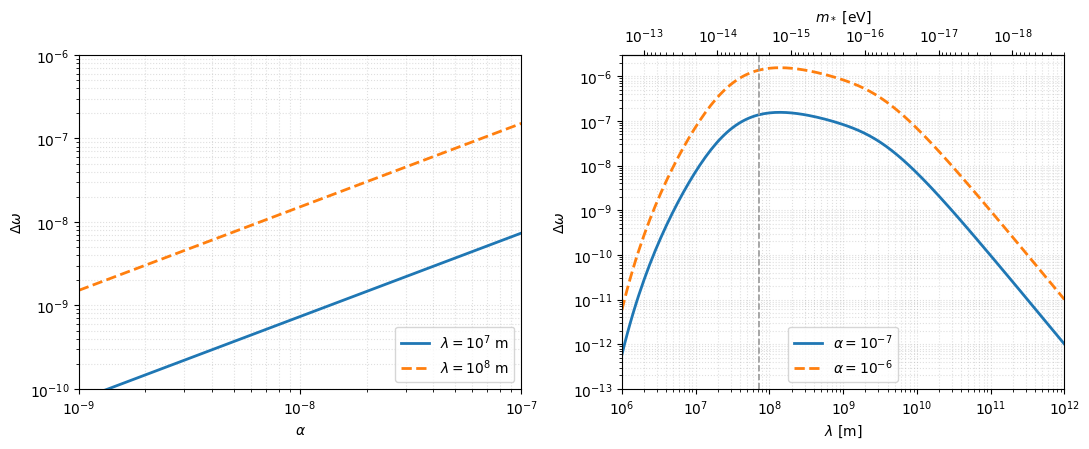

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.0, 4.6))

# left: drift vs coupling alpha, at fixed range lambda
alpha = np.logspace(-9, -7, 50)
for lam0, ls in [(1e7, "C0-"), (1e8, "C1--")]:
    axL.loglog(alpha, alpha * abs(g_finite_size(lam0)), ls, lw=2.0,
               label=rf"$\lambda = 10^{{{int(np.log10(lam0))}}}$ m")
style_log(axL, (1e-9, 1e-7), (1e-10, 1e-6), r"$\alpha$", r"$\Delta\omega$",
          decades(-9, -7), decades(-10, -6))
axL.legend(loc="lower right")

# right: drift vs range lambda, at fixed coupling alpha
lam = np.logspace(6, 12, 160)
g = np.abs(g_finite_size(lam))
for a0, ls in [(1e-7, "C0-"), (1e-6, "C1--")]:
    axR.loglog(lam, a0 * g, ls, lw=2.0, label=rf"$\alpha = 10^{{{int(np.log10(a0))}}}$")
axR.axvline(R_J_M, ls="--", color="0.6", lw=1.2)
style_log(axR, (1e6, 1e12), (1e-13, 3e-6), r"$\lambda$ [m]", r"$\Delta\omega$",
          decades(6, 12), decades(-13, -6))
axR.legend(loc="lower center")
add_mass_axis(axR, range(-13, -19, -1))

fig.tight_layout(); plt.show()

## Figure 4 - Juno fifth-force bound

`alpha_limit(lambda) = sigma_omega / |g(lambda)|`: the smallest detectable coupling at each range.

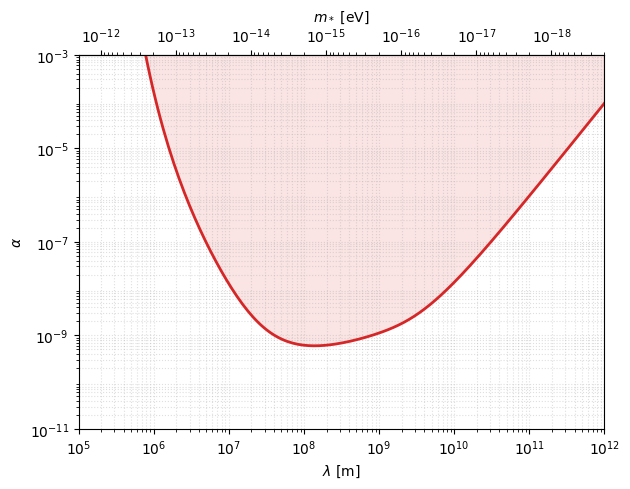

best bound: alpha >~ 5.98e-10 at lambda = 1.35e+08 m


In [7]:
lam = np.logspace(5, 12, 200)
alpha_limit = SIGMA_OMEGA / np.abs(g_finite_size(lam))

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.loglog(lam, alpha_limit, "C3-", lw=2.0)
ax.fill_between(lam, alpha_limit, 1e-3, color="C3", alpha=0.12)  # excluded region
style_log(ax, (1e5, 1e12), (1e-11, 1e-3), r"$\lambda$ [m]", r"$\alpha$",
          decades(5, 12), decades(-11, -3, 2))
add_mass_axis(ax, range(-12, -19, -1))
fig.tight_layout(); plt.show()

i = int(np.argmin(alpha_limit))
print(f"best bound: alpha >~ {alpha_limit[i]:.2e} at lambda = {lam[i]:.2e} m")

## Comparison with the updated covariance (Kaspi et al. 2023)

The `[GM, J2..J10]` block below is sliced from the updated covariance of Kaspi et, al. (https://www.nature.com/articles/s41550-023-02077-8). We run the same pipeline on both matrices as-is and compare the 95% C.L. bound (`2 sigma_omega / |g|`) via overlay. The old/new improvement is assuming that a direct comparision between the raw values of the matrix when truncated to only include the relevant 10 by 10 subsection is allowed.

sigma_omega  old (Durante) = 9.332e-10
sigma_omega  new (PJ37)    = 3.523e-10
  improvement factor = 2.65x


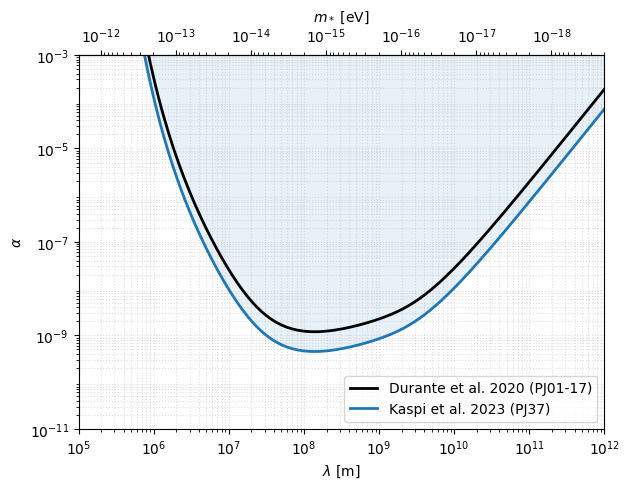

best bound old: alpha >~ 1.20e-09 at lambda = 1.35e+08 m
best bound new: alpha >~ 4.52e-10 at lambda = 1.35e+08 m
  alpha_min improvement factor = 2.65x


In [8]:
# [GM, J2..J10] block sliced from the updated solution from Kaspi that uses 37 perijoves.
COV_GM_J_NEW = np.array([
    [6.4513, 1.5341e-10, -8.1902e-11, 2.4929e-11, -2.1564e-11, 2.9784e-11, 2.4965e-13, 1.8789e-11, 1.8533e-11, -9.9771e-13],
    [1.5341e-10, 1.2282e-19, -2.7792e-20, -3.1090e-20, -2.8738e-20, 4.9996e-21, -4.5955e-20, 6.4584e-21, -3.2191e-20, 1.2000e-20],
    [-8.1902e-11, -2.7792e-20, 1.5058e-19, -3.4613e-20, 2.5293e-20, -7.6736e-20, 6.1071e-20, -1.1847e-19, 6.4399e-20, -1.0093e-19],
    [2.4929e-11, -3.1090e-20, -3.4613e-20, 1.0693e-19, -4.9797e-20, 6.1540e-20, -9.4627e-20, 9.3630e-20, -1.3475e-19, 7.2188e-20],
    [-2.1564e-11, -2.8738e-20, 2.5293e-20, -4.9797e-20, 1.5313e-19, -1.3578e-19, 1.8105e-19, -2.0490e-19, 2.2052e-19, -2.2749e-19],
    [2.9784e-11, 4.9996e-21, -7.6736e-20, 6.1540e-20, -1.3578e-19, 2.9813e-19, -3.3425e-19, 4.3801e-19, -4.4101e-19, 4.4977e-19],
    [2.4965e-13, -4.5955e-20, 6.1071e-20, -9.4627e-20, 1.8105e-19, -3.3425e-19, 6.5354e-19, -7.3508e-19, 9.1248e-19, -8.0954e-19],
    [1.8789e-11, 6.4584e-21, -1.1847e-19, 9.3630e-20, -2.0490e-19, 4.3801e-19, -7.3508e-19, 1.2007e-18, -1.2972e-18, 1.4534e-18],
    [1.8533e-11, -3.2191e-20, 6.4399e-20, -1.3475e-19, 2.2052e-19, -4.4101e-19, 9.1248e-19, -1.2972e-18, 1.8493e-18, -1.8084e-18],
    [-9.9771e-13, 1.2000e-20, -1.0093e-19, 7.2188e-20, -2.2749e-19, 4.4977e-19, -8.0954e-19, 1.4534e-18, -1.8084e-18, 2.3855e-18],
])

grad_cmp = gradient_vector(A_KM, ECC, INC, OMEGA, R_J_KM, N_MAX, apply_normalization=False)
SIGMA_OMEGA_NEW = np.sqrt(grad_cmp @ COV_GM_J_NEW @ grad_cmp)
print(f"sigma_omega  old (Durante) = {SIGMA_OMEGA:.3e}")
print(f"sigma_omega  new (PJ37)    = {SIGMA_OMEGA_NEW:.3e}")
print(f"  improvement factor = {SIGMA_OMEGA / SIGMA_OMEGA_NEW:.2f}x")

lam = np.logspace(5, 12, 200)
g_abs = np.abs(g_finite_size(lam))
alpha_old = 2.0 * SIGMA_OMEGA / g_abs
alpha_new = 2.0 * SIGMA_OMEGA_NEW / g_abs

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.loglog(lam, alpha_old, "k-", lw=2.0, label="Durante et al. 2020 (PJ01-17)")
ax.loglog(lam, alpha_new, "C0-", lw=2.0, label="Kaspi et al. 2023 (PJ37)")
ax.fill_between(lam, alpha_new, 1e-3, color="C0", alpha=0.10)
style_log(ax, (1e5, 1e12), (1e-11, 1e-3), r"$\lambda$ [m]", r"$\alpha$",
          decades(5, 12), decades(-11, -3, 2))
add_mass_axis(ax, range(-12, -19, -1))
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

io, inw = int(np.argmin(alpha_old)), int(np.argmin(alpha_new))
print(f"best bound old: alpha >~ {alpha_old[io]:.2e} at lambda = {lam[io]:.2e} m")
print(f"best bound new: alpha >~ {alpha_new[inw]:.2e} at lambda = {lam[inw]:.2e} m")
print(f"  alpha_min improvement factor = {alpha_old[io] / alpha_new[inw]:.2f}x")

## Figure 3 (right): `sigma_omega` versus harmonic truncation `N`

Reproduces the right panel of Fig. 3 (Singh et al. JHEP 01 (2025) 098): `sigma_omega`
for the conservative first-orbit geometry `i = 1.57, omega = 3.08`, as a function of how
many zonal harmonics `J_l` are kept in the covariance contraction. It rises from
`~0.81e-9` at `N=2` and saturates near `~0.935e-9` by `N~12`, flat out to `N=30`.

The Appendix-B derivatives above only cover `l = 2..10`. To reach `N = 30` we use the
**Gauss planetary-equations** model translated from the Mathematica notebook `J_calc.nb`:
the perturbing force from the zonal potential is projected onto radial/transverse/normal
components and fed into the secularly-averaged Gauss equations for `Omega` and `omega`.
It reproduces `B.1-B.9` to `~1e-14` and extends to arbitrary `l`.

In [9]:
from numpy.polynomial import legendre as _Leg

def _legP(m, x):
    c = np.zeros(m + 1); c[m] = 1.0
    return _Leg.legval(x, c)

def _legP_deriv(m, x):
    c = np.zeros(m + 1); c[m] = 1.0
    return _Leg.legval(x, _Leg.legder(c))

def domega_dJl_gauss(m, a=A_KM, e=ECC, inc=INC, omega=OMEGA, RJ=R_J_KM, n_f=20000):
    """d<Delta omega_g>/dJ_m (per orbit), Gauss planetary-equations model from J_calc.nb.

    The zonal potential U_m = -(mu/r)(RJ/r)^m P_m(z/r) J_m gives a force that, projected
    onto radial/transverse/normal (R-T-N) components with z -> r sin(i) sin(theta), is
        F_R =  (1+m)(RJ/r)^m (mu/r^2) P_m(s)
        F_T = -(RJ/r)^m (mu/r^2) sin(i) cos(theta) P_m'(s)
        F_N = -(RJ/r)^m (mu/r^2) cos(i)            P_m'(s),   s = sin(i) sin(theta).
    (The notebook writes these with P_{m+1}; the Legendre recurrence makes the factor
     (s P_m - P_{m+1})/(s^2-1) = -P_m'(s)/(m+1), regular at the poles s -> +/-1.)
    Secularly averaging the Gauss equations over one orbit (f = theta - omega,
    r = a(1-e^2)/(1+e cos f)) gives the time-averaged rate omega_m; the per-orbit drift
    d<Delta omega>/dJ_m = (2 pi / n) omega_m, in which n and mu cancel.
    """
    theta = np.linspace(0.0, 2.0 * np.pi, n_f)
    f = theta - omega
    cos_f, sin_f = np.cos(f), np.sin(f)
    one_ecf = 1.0 + e * cos_f
    r = a * (1.0 - e**2) / one_ecf
    s = np.sin(inc) * np.sin(theta)
    Pm, dPm = _legP(m, s), _legP_deriv(m, s)
    RJr_m = (RJ / r) ** m
    FR = (1.0 + m) * RJr_m * Pm                       # F_R r^2/mu
    FT = -RJr_m * np.sin(inc) * np.cos(theta) * dPm   # F_T r^2/mu
    FN = -RJr_m * np.cos(inc) * dPm                   # F_N r^2/mu
    term_omega = (-FR * cos_f + FT * (2.0 + e * cos_f) * sin_f / one_ecf) / e
    term_Omega = FN * np.sin(theta) / (np.sin(inc) * one_ecf)
    return float(np.trapezoid(term_omega - np.cos(inc) * term_Omega, theta))

# Cross-check the Gauss model against the analytic Appendix-B coefficients (l = 2..10):
_chk = {l: (domega_dJl(l, A_KM, ECC, INC, OMEGA, R_J_KM), domega_dJl_gauss(l)) for l in (2, 5, 10)}
print("B.l vs Gauss  (l=2,5,10):")
for l, (ana, gau) in _chk.items():
    print(f"  l={l:2d}: {ana: .6e}  vs  {gau: .6e}   rel.err {abs(gau-ana)/abs(ana):.1e}")

B.l vs Gauss  (l=2,5,10):
  l= 2: -1.068185e+00  vs  -1.068185e+00   rel.err 2.1e-16
  l= 5: -3.473286e-02  vs  -3.473286e-02   rel.err 3.0e-15
  l=10: -3.773962e-03  vs  -3.773962e-03   rel.err 9.2e-14


In [10]:
# [GM, J2, ..., J30] block of the Durante covariance (fully-normalised), extended from
# the 10x10 block above so the truncation can be pushed out to N = 30.
COV_GM_J30 = np.array([
    [70.46, 2.318e-09, -4.629e-11, -1.584e-10, -2.058e-11, 2.678e-11, -4.552e-11, 7.314e-11, -1.096e-10, 2.1e-10, -2.722e-10, 5.026e-10, -6.13e-10, 1.049e-09, -1.235e-09, 1.956e-09, -2.212e-09, 3.217e-09, -3.409e-09, 4.479e-09, -4.301e-09, 5.022e-09, -4.203e-09, 4.295e-09, -2.974e-09, 2.602e-09, -1.353e-09, 9.777e-10, -2.961e-10, 1.655e-10],
    [2.318e-09, 5.703e-19, -4.222e-19, 2.918e-19, -3.743e-19, 4.109e-19, -5.579e-19, 6.234e-19, -8.617e-19, 9.329e-19, -1.26e-18, 1.212e-18, -1.58e-18, 1.173e-18, -1.389e-18, 2.53e-19, -8.822e-20, -1.976e-18, 2.395e-18, -4.957e-18, 4.998e-18, -7.095e-18, 6.07e-18, -6.911e-18, 4.853e-18, -4.562e-18, 2.412e-18, -1.84e-18, 5.738e-19, -3.322e-19],
    [-4.629e-11, -4.222e-19, 1.541e-18, -5.734e-19, 1.156e-18, -1.152e-18, 1.814e-18, -2.355e-18, 3.183e-18, -4.705e-18, 5.763e-18, -8.974e-18, 1.017e-17, -1.592e-17, 1.688e-17, -2.588e-17, 2.576e-17, -3.803e-17, 3.539e-17, -4.946e-17, 4.242e-17, -5.493e-17, 4.208e-17, -4.918e-17, 3.183e-17, -3.256e-17, 1.605e-17, -1.381e-17, 3.979e-18, -2.711e-18],
    [-1.584e-10, 2.918e-19, -5.734e-19, 6.411e-19, -7.783e-19, 1.182e-18, -1.416e-18, 2.131e-18, -2.469e-18, 3.625e-18, -3.984e-18, 5.603e-18, -5.577e-18, 7.478e-18, -6.385e-18, 8.284e-18, -5.491e-18, 7.265e-18, -2.729e-18, 4.742e-18, 5.34e-19, 2.402e-18, 2.122e-18, 1.703e-18, 1.394e-18, 1.981e-18, 1.091e-19, 1.56e-18, -1.897e-19, 5.051e-19],
    [-2.058e-11, -3.743e-19, 1.156e-18, -7.783e-19, 1.614e-18, -1.956e-18, 3.27e-18, -4.267e-18, 6.421e-18, -8.559e-18, 1.199e-17, -1.575e-17, 2.072e-17, -2.642e-17, 3.275e-17, -4.009e-17, 4.647e-17, -5.38e-17, 5.74e-17, -6.174e-17, 5.933e-17, -5.818e-17, 4.893e-17, -4.283e-17, 3.013e-17, -2.285e-17, 1.23e-17, -7.696e-18, 2.491e-18, -1.176e-18],
    [2.678e-11, 4.109e-19, -1.152e-18, 1.182e-18, -1.956e-18, 3.418e-18, -4.95e-18, 8.233e-18, -1.134e-17, 1.798e-17, -2.386e-17, 3.611e-17, -4.618e-17, 6.662e-17, -8.158e-17, 1.112e-16, -1.285e-16, 1.631e-16, -1.744e-16, 2.031e-16, -1.96e-16, 2.057e-16, -1.737e-16, 1.608e-16, -1.133e-16, 8.967e-17, -4.805e-17, 3.096e-17, -9.898e-18, 4.735e-18],
    [-4.552e-11, -5.579e-19, 1.814e-18, -1.416e-18, 3.27e-18, -4.95e-18, 9.162e-18, -1.392e-17, 2.286e-17, -3.384e-17, 5.17e-17, -7.392e-17, 1.064e-16, -1.456e-16, 1.97e-16, -2.544e-16, 3.196e-16, -3.83e-16, 4.4e-16, -4.802e-16, 4.944e-16, -4.805e-16, 4.313e-16, -3.622e-16, 2.717e-16, -1.881e-16, 1.087e-16, -5.693e-17, 2.04e-17, -6.597e-18],
    [7.314e-11, 6.234e-19, -2.355e-18, 2.131e-18, -4.267e-18, 8.233e-18, -1.392e-17, 2.529e-17, -3.929e-17, 6.622e-17, -9.756e-17, 1.539e-16, -2.158e-16, 3.185e-16, -4.216e-16, 5.786e-16, -7.132e-16, 9.003e-16, -1.017e-15, 1.164e-15, -1.179e-15, 1.204e-15, -1.063e-15, 9.435e-16, -6.941e-16, 5.155e-16, -2.898e-16, 1.686e-16, -5.752e-17, 2.284e-17],
    [-1.096e-10, -8.617e-19, 3.183e-18, -2.469e-18, 6.421e-18, -1.134e-17, 2.286e-17, -3.929e-17, 6.932e-17, -1.124e-16, 1.819e-16, -2.781e-16, 4.178e-16, -5.994e-16, 8.358e-16, -1.116e-15, 1.432e-15, -1.757e-15, 2.052e-15, -2.279e-15, 2.376e-15, -2.341e-15, 2.124e-15, -1.802e-15, 1.364e-15, -9.519e-16, 5.546e-16, -2.918e-16, 1.054e-16, -3.397e-17],
    [2.1e-10, 9.329e-19, -4.705e-18, 3.625e-18, -8.559e-18, 1.798e-17, -3.384e-17, 6.622e-17, -1.124e-16, 2.001e-16, -3.161e-16, 5.162e-16, -7.625e-16, 1.149e-15, -1.58e-15, 2.191e-15, -2.782e-15, 3.526e-15, -4.075e-15, 4.664e-15, -4.818e-15, 4.894e-15, -4.398e-15, 3.864e-15, -2.891e-15, 2.109e-15, -1.208e-15, 6.802e-16, -2.379e-16, 8.812e-17],
    [-2.722e-10, -1.26e-18, 5.763e-18, -3.984e-18, 1.199e-17, -2.386e-17, 5.17e-17, -9.756e-17, 1.819e-16, -3.161e-16, 5.33e-16, -8.553e-16, 1.324e-15, -1.965e-15, 2.798e-15, -3.827e-15, 4.99e-15, -6.235e-15, 7.365e-15, -8.3e-15, 8.736e-15, -8.711e-15, 7.963e-15, -6.83e-15, 5.202e-15, -3.666e-15, 2.145e-15, -1.141e-15, 4.131e-16, -1.353e-16],
    [5.026e-10, 1.212e-18, -8.974e-18, 5.603e-18, -1.575e-17, 3.611e-17, -7.392e-17, 1.539e-16, -2.781e-16, 5.162e-16, -8.553e-16, 1.438e-15, -2.203e-15, 3.386e-15, -4.788e-15, 6.734e-15, -8.734e-15, 1.118e-14, -1.314e-14, 1.514e-14, -1.586e-14, 1.616e-14, -1.471e-14, 1.292e-14, -9.778e-15, 7.104e-15, -4.115e-15, 2.292e-15, -8.129e-16, 2.922e-16],
    [-6.13e-10, -1.58e-18, 1.017e-17, -5.577e-18, 2.072e-17, -4.618e-17, 1.064e-16, -2.158e-16, 4.178e-16, -7.625e-16, 1.324e-15, -2.203e-15, 3.49e-15, -5.326e-15, 7.729e-15, -1.08e-14, 1.43e-14, -1.819e-14, 2.175e-14, -2.487e-14, 2.643e-14, -2.668e-14, 2.459e-14, -2.132e-14, 1.634e-14, -1.164e-14, 6.844e-15, -3.681e-15, 1.336e-15, -4.446e-16],
    [1.049e-09, 1.173e-18, -1.592e-17, 7.478e-18, -2.642e-17, 6.662e-17, -1.456e-16, 3.185e-16, -5.994e-16, 1.149e-15, -1.965e-15, 3.386e-15, -5.326e-15, 8.354e-15, -1.208e-14, 1.727e-14, -2.283e-14, 2.96e-14, -3.535e-14, 4.114e-14, -4.369e-14, 4.487e-14, -4.128e-14, 3.647e-14, -2.787e-14, 2.03e-14, -1.187e-14, 6.601e-15, -2.364e-15, 8.411e-16],
    [-1.235e-09, -1.389e-18, 1.688e-17, -6.385e-18, 3.275e-17, -8.158e-17, 1.97e-16, -4.216e-16, 8.358e-16, -1.58e-15, 2.798e-15, -4.788e-15, 7.729e-15, -1.208e-14, 1.784e-14, -2.545e-14, 3.421e-14, -4.428e-14, 5.366e-14, -6.228e-14, 6.695e-14, -6.846e-14, 6.369e-14, -5.586e-14, 4.314e-14, -3.105e-14, 1.837e-14, -9.99e-15, 3.64e-15, -1.23e-15],
    [1.956e-09, 2.53e-19, -2.588e-17, 8.284e-18, -4.009e-17, 1.112e-16, -2.544e-16, 5.786e-16, -1.116e-15, 2.191e-15, -3.827e-15, 6.734e-15, -1.08e-14, 1.727e-14, -2.545e-14, 3.702e-14, -4.977e-14, 6.553e-14, -7.948e-14, 9.372e-14, -1.008e-13, 1.047e-13, -9.742e-14, 8.683e-14, -6.7e-14, 4.915e-14, -2.898e-14, 1.619e-14, -5.845e-15, 2.081e-15],
    [-2.212e-09, -8.822e-20, 2.576e-17, -5.491e-18, 4.647e-17, -1.285e-16, 3.196e-16, -7.132e-16, 1.432e-15, -2.782e-15, 4.99e-15, -8.734e-15, 1.43e-14, -2.283e-14, 3.421e-14, -4.977e-14, 6.791e-14, -8.947e-14, 1.099e-13, -1.296e-13, 1.41e-13, -1.462e-13, 1.374e-13, -1.221e-13, 9.511e-14, -6.926e-14, 4.126e-14, -2.272e-14, 8.316e-15, -2.856e-15],
    [3.217e-09, -1.976e-18, -3.803e-17, 7.265e-18, -5.38e-17, 1.631e-16, -3.83e-16, 9.003e-16, -1.757e-15, 3.526e-15, -6.235e-15, 1.118e-14, -1.819e-14, 2.96e-14, -4.428e-14, 6.553e-14, -8.947e-14, 1.197e-13, -1.473e-13, 1.763e-13, -1.921e-13, 2.022e-13, -1.903e-13, 1.716e-13, -1.337e-13, 9.91e-14, -5.893e-14, 3.323e-14, -1.208e-14, 4.34e-15],
    [-3.409e-09, 2.395e-18, 3.539e-17, -2.729e-18, 5.74e-17, -1.744e-16, 4.4e-16, -1.017e-15, 2.052e-15, -4.075e-15, 7.365e-15, -1.314e-14, 2.175e-14, -3.535e-14, 5.366e-14, -7.948e-14, 1.099e-13, -1.473e-13, 1.834e-13, -2.198e-13, 2.421e-13, -2.548e-13, 2.422e-13, -2.181e-13, 1.716e-13, -1.266e-13, 7.604e-14, -4.244e-14, 1.563e-14, -5.466e-15],
    [4.479e-09, -4.957e-18, -4.946e-17, 4.742e-18, -6.174e-17, 2.031e-16, -4.802e-16, 1.164e-15, -2.279e-15, 4.664e-15, -8.3e-15, 1.514e-14, -2.487e-14, 4.114e-14, -6.228e-14, 9.372e-14, -1.296e-13, 1.763e-13, -2.198e-13, 2.671e-13, -2.949e-13, 3.149e-13, -2.998e-13, 2.741e-13, -2.158e-13, 1.621e-13, -9.722e-14, 5.554e-14, -2.033e-14, 7.42e-15],
    [-4.301e-09, 4.998e-18, 4.242e-17, 5.34e-19, 5.933e-17, -1.96e-16, 4.944e-16, -1.179e-15, 2.376e-15, -4.818e-15, 8.736e-15, -1.586e-14, 2.643e-14, -4.369e-14, 6.695e-14, -1.008e-13, 1.41e-13, -1.921e-13, 2.421e-13, -2.949e-13, 3.287e-13, -3.516e-13, 3.379e-13, -3.09e-13, 2.456e-13, -1.84e-13, 1.115e-13, -6.322e-14, 2.342e-14, -8.372e-15],
    [5.022e-09, -7.095e-18, -5.493e-17, 2.402e-18, -5.818e-17, 2.057e-16, -4.805e-16, 1.204e-15, -2.341e-15, 4.894e-15, -8.711e-15, 1.616e-14, -2.668e-14, 4.487e-14, -6.846e-14, 1.047e-13, -1.462e-13, 2.022e-13, -2.548e-13, 3.149e-13, -3.516e-13, 3.815e-13, -3.674e-13, 3.413e-13, -2.715e-13, 2.071e-13, -1.254e-13, 7.288e-14, -2.686e-14, 1.003e-14],
    [-4.203e-09, 6.07e-18, 4.208e-17, 2.122e-18, 4.893e-17, -1.737e-16, 4.313e-16, -1.063e-15, 2.124e-15, -4.398e-15, 7.963e-15, -1.471e-14, 2.459e-14, -4.128e-14, 6.369e-14, -9.742e-14, 1.374e-13, -1.903e-13, 2.422e-13, -2.998e-13, 3.379e-13, -3.674e-13, 3.571e-13, -3.32e-13, 2.666e-13, -2.032e-13, 1.242e-13, -7.181e-14, 2.678e-14, -9.824e-15],
    [4.295e-09, -6.911e-18, -4.918e-17, 1.703e-18, -4.283e-17, 1.608e-16, -3.622e-16, 9.435e-16, -1.802e-15, 3.864e-15, -6.83e-15, 1.292e-14, -2.132e-14, 3.647e-14, -5.586e-14, 8.683e-14, -1.221e-13, 1.716e-13, -2.181e-13, 2.741e-13, -3.09e-13, 3.413e-13, -3.32e-13, 3.14e-13, -2.523e-13, 1.963e-13, -1.199e-13, 7.122e-14, -2.641e-14, 1.017e-14],
    [-2.974e-09, 4.853e-18, 3.183e-17, 1.394e-18, 3.013e-17, -1.133e-16, 2.717e-16, -6.941e-16, 1.364e-15, -2.891e-15, 5.202e-15, -9.778e-15, 1.634e-14, -2.787e-14, 4.314e-14, -6.7e-14, 9.511e-14, -1.337e-13, 1.716e-13, -2.158e-13, 2.456e-13, -2.715e-13, 2.666e-13, -2.523e-13, 2.048e-13, -1.591e-13, 9.821e-14, -5.804e-14, 2.181e-14, -8.254e-15],
    [2.602e-09, -4.562e-18, -3.256e-17, 1.981e-18, -2.285e-17, 8.967e-17, -1.881e-16, 5.155e-16, -9.519e-16, 2.109e-15, -3.666e-15, 7.104e-15, -1.164e-14, 2.03e-14, -3.105e-14, 4.915e-14, -6.926e-14, 9.91e-14, -1.266e-13, 1.621e-13, -1.84e-13, 2.071e-13, -2.032e-13, 1.963e-13, -1.591e-13, 1.267e-13, -7.799e-14, 4.769e-14, -1.777e-14, 7.141e-15],
    [-1.353e-09, 2.412e-18, 1.605e-17, 1.091e-19, 1.23e-17, -4.805e-17, 1.087e-16, -2.898e-16, 5.546e-16, -1.208e-15, 2.145e-15, -4.115e-15, 6.844e-15, -1.187e-14, 1.837e-14, -2.898e-14, 4.126e-14, -5.893e-14, 7.604e-14, -9.722e-14, 1.115e-13, -1.254e-13, 1.242e-13, -1.199e-13, 9.821e-14, -7.799e-14, 4.86e-14, -2.95e-14, 1.116e-14, -4.393e-15],
    [9.777e-10, -1.84e-18, -1.381e-17, 1.56e-18, -7.696e-18, 3.096e-17, -5.693e-17, 1.686e-16, -2.918e-16, 6.802e-16, -1.141e-15, 2.292e-15, -3.681e-15, 6.601e-15, -9.99e-15, 1.619e-14, -2.272e-14, 3.323e-14, -4.244e-14, 5.554e-14, -6.322e-14, 7.288e-14, -7.181e-14, 7.122e-14, -5.804e-14, 4.769e-14, -2.95e-14, 1.878e-14, -7.002e-15, 2.998e-15],
    [-2.961e-10, 5.738e-19, 3.979e-18, -1.897e-19, 2.491e-18, -9.898e-18, 2.04e-17, -5.752e-17, 1.054e-16, -2.379e-16, 4.131e-16, -8.129e-16, 1.336e-15, -2.364e-15, 3.64e-15, -5.845e-15, 8.316e-15, -1.208e-14, 1.563e-14, -2.033e-14, 2.342e-14, -2.686e-14, 2.678e-14, -2.641e-14, 2.181e-14, -1.777e-14, 1.116e-14, -7.002e-15, 2.667e-15, -1.103e-15],
    [1.655e-10, -3.322e-19, -2.711e-18, 5.051e-19, -1.176e-18, 4.735e-18, -6.597e-18, 2.284e-17, -3.397e-17, 8.812e-17, -1.353e-16, 2.922e-16, -4.446e-16, 8.411e-16, -1.23e-15, 2.081e-15, -2.856e-15, 4.34e-15, -5.466e-15, 7.42e-15, -8.372e-15, 1.003e-14, -9.824e-15, 1.017e-14, -8.254e-15, 7.141e-15, -4.393e-15, 2.998e-15, -1.103e-15, 5.289e-16],
])

def gradient_vector_gauss(a, e, inc, omega, RJ, n_max):
    """[d/dmu, d/dJ2, ..., d/dJ_nmax] with the zonal terms from the Gauss model."""
    grad = [domega_dmu(a, e)]
    for l in range(2, n_max + 1):
        grad.append(domega_dJl_gauss(l, a, e, inc, omega, RJ))
    return np.array(grad)

def sigma_omega_N(n_max):
    g = gradient_vector_gauss(A_KM, ECC, INC, OMEGA, R_J_KM, n_max)
    return float(np.sqrt(g @ COV_GM_J30[:n_max, :n_max] @ g))

# sanity: the J2..J10 block must match the 10x10 COV_GM_J embedded earlier
print(f"COV_GM_J30 vs COV_GM_J (10x10 block) max abs diff = "
      f"{np.max(np.abs(COV_GM_J30[:10, :10] - COV_GM_J)):.2e}")

COV_GM_J30 vs COV_GM_J (10x10 block) max abs diff = 0.00e+00


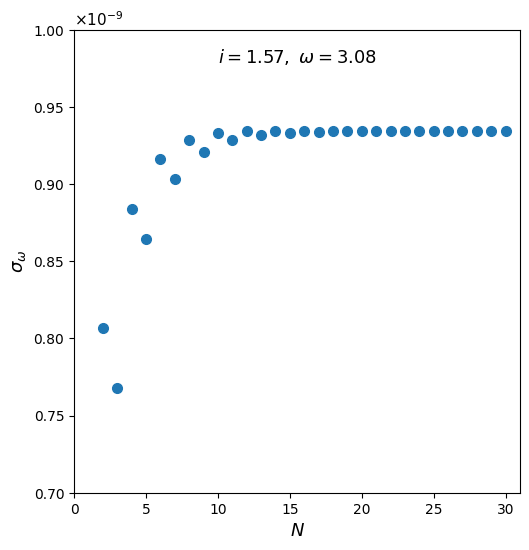

  N= 2: sigma_omega = 8.0667e-10
  N= 3: sigma_omega = 7.6820e-10
  N= 4: sigma_omega = 8.8393e-10
  N= 5: sigma_omega = 8.6436e-10
  N= 6: sigma_omega = 9.1642e-10
  N= 7: sigma_omega = 9.0350e-10
  N= 8: sigma_omega = 9.2874e-10
  N= 9: sigma_omega = 9.2062e-10
  N=10: sigma_omega = 9.3320e-10
  N=11: sigma_omega = 9.2840e-10
  N=12: sigma_omega = 9.3447e-10
  N=13: sigma_omega = 9.3189e-10
  N=14: sigma_omega = 9.3463e-10
  N=15: sigma_omega = 9.3340e-10
  N=16: sigma_omega = 9.3451e-10
  N=17: sigma_omega = 9.3401e-10
  N=18: sigma_omega = 9.3440e-10
  N=19: sigma_omega = 9.3423e-10
  N=20: sigma_omega = 9.3434e-10
  N=21: sigma_omega = 9.3430e-10
  N=22: sigma_omega = 9.3432e-10
  N=23: sigma_omega = 9.3431e-10
  N=24: sigma_omega = 9.3432e-10
  N=25: sigma_omega = 9.3432e-10
  N=26: sigma_omega = 9.3432e-10
  N=27: sigma_omega = 9.3432e-10
  N=28: sigma_omega = 9.3432e-10
  N=29: sigma_omega = 9.3432e-10
  N=30: sigma_omega = 9.3432e-10

plateau (N>=12) sigma_omega = 9.3416e-10  

In [11]:
N = np.arange(2, 31)
sig = np.array([sigma_omega_N(n) for n in N])

fig, ax = plt.subplots(figsize=(5.4, 5.6))
ax.plot(N, sig / 1e-9, "o", color="#1f77b4", ms=7)
ax.set_xlim(0, 31)
ax.set_ylim(0.70, 1.00)
ax.set_xlabel(r"$N$", fontsize=13)
ax.set_ylabel(r"$\sigma_\omega$", fontsize=13)
ax.text(0.5, 0.93, rf"$i = {INC},\ \omega = {OMEGA}$",
        transform=ax.transAxes, ha="center", fontsize=13)
ax.text(0.0, 1.01, r"$\times 10^{-9}$", transform=ax.transAxes, fontsize=11)
fig.tight_layout()
plt.show()

for n, s in zip(N, sig):
    print(f"  N={n:2d}: sigma_omega = {s:.4e}")
print(f"\nplateau (N>=12) sigma_omega = {sig[N >= 12].mean():.4e}  "
      f"(paper Fig. 3 right ~0.935e-9)")

## Figure 3 (right) for the updated matrix (Kaspi et al. 2023, PJ37)

The same `sigma_omega` vs harmonic-truncation `N` curve, but contracting the gradient
with the updated Kaspi matrix instead of Durante 2020. We embed the
`[GM, J2..J30]` block of the new solution and overlay both curves so the improvement is visible at every truncation. The new solution drives `sigma_omega` down by ~2.6x.

In [12]:
# [GM, J2, ..., J30] block of the updated PJ37 solution (Kaspi et al. 2023),
COV_GM_J30_NEW = np.array([
    [6.451264483898, 1.534080842857e-10, -8.190238344748e-11, 2.492885185902e-11, -2.156417998584e-11, 2.978442783574e-11, 2.496509998339e-13, 1.878926285444e-11, 1.853333450462e-11, -9.977106731595e-13, 8.719951025096e-12, 6.028440149262e-14, -3.042026464052e-13, -3.584743369499e-14, 2.658715154555e-13, -6.219658688192e-13, -9.451064118724e-13, -1.0322219786e-12, -2.171506384478e-12, -2.625480799558e-12, -1.669975927987e-12, -1.196315661837e-12, -8.936985676201e-13, 2.659244173265e-13, 1.089051807185e-12, 1.068269138099e-12, 1.059400058119e-12, 1.019110944107e-12, 6.393750811085e-13, 3.252867800616e-13],
    [1.534080842857e-10, 1.228211367881e-19, -2.779187003751e-20, -3.109029057862e-20, -2.873811362255e-20, 4.999567990766e-21, -4.59545431494e-20, 6.458353783631e-21, -3.219132401696e-20, 1.200030438575e-20, -1.161488900748e-20, -8.832838025914e-23, -1.148104596932e-21, -1.180686517538e-21, -6.606803598107e-22, -1.041857468278e-21, -1.293521437174e-21, -7.336476793016e-22, -4.036326480305e-22, -1.715471442585e-22, 2.593387301633e-22, 3.376556640573e-22, 1.788715060698e-22, 2.138845466305e-22, 2.192317185843e-22, 4.032336853874e-23, -5.99735331164e-23, -1.308286186345e-23, -8.19025320687e-24, -9.222478883197e-23],
    [-8.190238344748e-11, -2.779187003751e-20, 1.505835789941e-19, -3.461326343754e-20, 2.529331608479e-20, -7.673618672841e-20, 6.107087706818e-20, -1.184685929467e-19, 6.439928869931e-20, -1.009323123581e-19, 4.674890918603e-20, -3.997543651057e-20, 4.320221246118e-21, -1.365957836002e-21, -5.458611039247e-21, -1.258195505675e-22, 9.260484531046e-22, -1.041475075727e-21, 5.875946401481e-22, 9.737155143982e-22, -2.761694425497e-22, 1.893513307432e-22, 6.79176371694e-22, 7.545643621386e-23, -9.232307678115e-23, 2.065282020571e-22, 8.846255754034e-23, -1.361431108536e-22, -2.797333694768e-23, 1.896857452049e-23],
    [2.492885185902e-11, -3.109029057862e-20, -3.461326343754e-20, 1.06934956557e-19, -4.979712697073e-20, 6.153990166577e-20, -9.462718373468e-20, 9.362963516375e-20, -1.347508112974e-19, 7.218846728192e-20, -8.579325771951e-20, 2.515669338291e-20, -1.271807631833e-20, -6.445380883298e-21, 4.118620605568e-21, 3.902399653207e-22, 1.244668410505e-23, 2.53001870686e-21, 8.471695975775e-22, 5.1862328802e-22, 1.114854572734e-21, 1.860931399205e-22, -8.706719361953e-23, 1.669553979422e-22, -1.892658613033e-22, -3.244455958693e-22, -9.936747121246e-23, -1.193337634061e-22, -1.724716070486e-22, -2.481438167953e-23],
    [-2.156417998584e-11, -2.873811362255e-20, 2.529331608479e-20, -4.979712697073e-20, 1.531279165918e-19, -1.357758802384e-19, 1.810457377494e-19, -2.049049050082e-19, 2.20515678483e-19, -2.274861611307e-19, 1.287320562042e-19, -9.904505666116e-20, 1.032731295255e-20, -5.542206781062e-21, -1.255464330876e-20, 7.765159438693e-23, 5.534790159423e-22, -1.447713443981e-21, 1.761794271931e-21, 9.310294738176e-22, 2.39949732452e-22, 1.503712182527e-21, 6.041267923877e-22, -9.236504605306e-23, 5.760408182607e-22, 1.914192091708e-22, -4.165524833427e-22, -3.088301091159e-23, 6.771464724612e-23, -3.239412343259e-22],
    [2.978442783574e-11, 4.999567990766e-21, -7.673618672841e-20, 6.153990166577e-20, -1.357758802384e-19, 2.981293487917e-19, -3.34248768326e-19, 4.380086578041e-19, -4.410107719662e-19, 4.497723473981e-19, -3.247237531166e-19, 1.791860400135e-19, -4.365102470411e-20, -8.566283738527e-21, 2.157509267389e-20, -3.320743098772e-21, -3.159616822576e-21, 6.521172379947e-21, -9.591714293741e-22, -1.125728037727e-21, 2.101330487717e-21, -8.56941131959e-22, -9.370199626507e-22, 7.322837820743e-22, -3.723185586916e-22, -5.966221050704e-22, 3.788687669821e-22, 7.051344895759e-23, -2.554728907865e-22, 2.64029488429e-22],
    [2.496509998339e-13, -4.59545431494e-20, 6.107087706818e-20, -9.462718373468e-20, 1.810457377494e-19, -3.34248768326e-19, 6.535369278773e-19, -7.350813937199e-19, 9.124815717221e-19, -8.095357313054e-19, 6.689821085586e-19, -3.694907020517e-19, 9.940972899819e-20, 1.296483132598e-20, -5.125129572428e-20, 8.723535777118e-21, 5.239521724089e-21, -1.645326161843e-20, 3.3036613628e-21, 3.44947487927e-21, -5.259354015136e-21, 1.957926398621e-21, 2.997627813723e-21, -1.311644330009e-21, 7.667593522409e-22, 1.820716120762e-21, -3.106746624772e-22, -1.228689012484e-22, 7.111382784278e-22, -2.919000166189e-22],
    [1.878926285444e-11, 6.458353783631e-21, -1.184685929467e-19, 9.362963516375e-20, -2.049049050082e-19, 4.380086578041e-19, -7.350813937199e-19, 1.200673290664e-18, -1.297222559678e-18, 1.45340219716e-18, -1.034454222534e-18, 7.28720578943e-19, -1.620799887985e-19, 1.735450075534e-20, 1.025578076695e-19, -1.730762110423e-20, -2.533054122658e-21, 2.817640177751e-20, -1.046033163763e-20, -6.567651891764e-21, 6.84519627059e-21, -6.684989890324e-21, -5.760612595007e-21, 2.083217994283e-21, -1.805714292513e-21, -2.40040748947e-21, 1.677985323824e-21, 7.692404504846e-22, -7.211010941485e-22, 1.197854606784e-21],
    [1.853333450462e-11, -3.219132401696e-20, 6.439928869931e-20, -1.347508112974e-19, 2.20515678483e-19, -4.410107719662e-19, 9.124815717221e-19, -1.297222559678e-18, 1.849255857446e-18, -1.808395029473e-18, 1.586780211566e-18, -9.115519323433e-19, 2.989742070255e-19, 2.224065699253e-20, -1.197222169021e-19, 3.911693224122e-20, 6.582033895535e-21, -3.967078888157e-20, 1.167085657988e-20, 3.754778501353e-21, -1.411405190443e-20, 5.34409943801e-21, 4.649412746746e-21, -4.486025127708e-21, 2.235631700633e-21, 3.643157688297e-21, -1.344913820844e-21, 7.76400076751e-23, 1.656978255443e-21, -8.536054223553e-22],
    [-9.977106731595e-13, 1.200030438575e-20, -1.009323123581e-19, 7.218846728192e-20, -2.274861611307e-19, 4.497723473981e-19, -8.095357313054e-19, 1.45340219716e-18, -1.808395029473e-18, 2.385494842267e-18, -1.814830744668e-18, 1.429578832994e-18, -3.452744625504e-19, 9.380046085756e-20, 2.042416238487e-19, -3.408181069102e-20, 1.602076375581e-20, 5.432589230464e-20, -2.125907125046e-20, -7.026313458327e-21, 1.09333902398e-20, -1.572467379379e-20, -1.020968836681e-20, 2.612378596198e-21, -5.639261721764e-21, -4.531745712883e-21, 3.350074106151e-21, 8.886129222782e-22, -1.242879403416e-21, 2.748554859804e-21],
    [8.719951025096e-12, -1.161488900748e-20, 4.674890918603e-20, -8.579325771951e-20, 1.287320562042e-19, -3.247237531166e-19, 6.689821085586e-19, -1.034454222534e-18, 1.586780211566e-18, -1.814830744668e-18, 1.875321133383e-18, -1.194629405579e-18, 4.904021798823e-19, -1.592966260185e-20, -1.374258698605e-19, 7.330243734421e-20, -2.185465729211e-21, -4.541833870981e-20, 2.118792804133e-20, 5.234932957466e-22, -1.75967023883e-20, 8.346279155274e-21, 3.473207964899e-21, -6.724367513314e-21, 3.223300229711e-21, 3.596949715585e-21, -2.445605046425e-21, 3.737297479309e-22, 1.925201022748e-21, -1.218480930138e-21],
    [6.028440149262e-14, -8.832838025914e-23, -3.997543651057e-20, 2.515669338291e-20, -9.904505666116e-20, 1.791860400135e-19, -3.694907020517e-19, 7.28720578943e-19, -9.115519323433e-19, 1.429578832994e-18, -1.194629405579e-18, 1.290935694126e-18, -3.723255167491e-19, 2.302737585196e-19, 1.779285354191e-19, -2.38138349806e-20, 5.305698937387e-20, 4.774786245376e-20, -1.983132123318e-20, 2.724893081843e-21, 6.336317435949e-21, -1.837313263857e-20, -8.377811892618e-21, -1.880692490156e-22, -8.011974958493e-21, -3.988764195072e-21, 2.769438368676e-21, 1.0313369289e-22, -6.291765357943e-22, 2.966266025751e-21],
    [-3.042026464052e-13, -1.148104596932e-21, 4.320221246118e-21, -1.271807631833e-20, 1.032731295255e-20, -4.365102470411e-20, 9.940972899819e-20, -1.620799887985e-19, 2.989742070255e-19, -3.452744625504e-19, 4.904021798823e-19, -3.723255167491e-19, 3.582126247983e-19, -9.096594349655e-20, 5.193860150915e-20, 5.344196151247e-20, -4.33860927914e-21, 1.111325263121e-20, 1.559389411436e-20, -4.968501877983e-21, -1.447426746656e-21, 2.453713911234e-21, -4.803674834802e-21, -3.521332319001e-21, 3.203265262791e-23, -1.843516478867e-21, -1.47497986956e-21, 5.317909901874e-22, -1.230438750266e-22, 3.360884519262e-23],
    [-3.584743369499e-14, -1.180686517538e-21, -1.365957836002e-21, -6.445380883298e-21, -5.542206781062e-21, -8.566283738527e-21, 1.296483132598e-20, 1.735450075534e-20, 2.224065699253e-20, 9.380046085756e-20, -1.592966260185e-20, 2.302737585196e-19, -9.096594349655e-20, 2.576905837343e-19, -3.630639642159e-20, 8.346221564157e-20, 4.730122888375e-20, 6.763380296895e-21, 1.999256860157e-20, 1.130885939781e-20, -5.137133151426e-21, -1.26529399633e-21, -1.551579730486e-21, -6.828956637228e-21, -4.154036724205e-21, -1.456951834515e-21, -2.185644469692e-21, -1.009037625964e-21, 4.017573556652e-22, 4.234240470521e-22],
    [2.658715154555e-13, -6.606803598107e-22, -5.458611039247e-21, 4.118620605568e-21, -1.255464330876e-20, 2.157509267389e-20, -5.125129572428e-20, 1.025578076695e-19, -1.197222169021e-19, 2.042416238487e-19, -1.374258698605e-19, 1.779285354191e-19, 5.193860150915e-20, -3.630639642159e-20, 2.113981693992e-19, -5.474677086315e-20, 7.993542032629e-20, 4.047520685797e-20, -4.991985354548e-22, 2.060735277333e-20, 1.141586447224e-20, -6.939789182021e-21, -3.25631532981e-22, -1.529771413254e-22, -6.982984521452e-21, -3.751382967104e-21, -3.874485399238e-22, -2.06649833438e-21, -1.283722214209e-21, 1.033333802264e-21],
    [-6.219658688192e-13, -1.041857468278e-21, -1.258195505675e-22, 3.902399653207e-22, 7.765159438693e-23, -3.320743098772e-21, 8.723535777118e-21, -1.730762110423e-20, 3.911693224122e-20, -3.408181069102e-20, 7.330243734421e-20, -2.38138349806e-20, 5.344196151247e-20, 8.346221564157e-20, -5.474677086315e-20, 1.735548836394e-19, -4.7504780102e-20, 6.795461173128e-20, 3.36281845937e-20, 1.51656418741e-21, 1.853614492773e-20, 1.039501710314e-20, -5.128786171696e-21, -3.572799919342e-22, -2.75180678658e-22, -6.049709942437e-21, -3.572986709796e-21, -7.701387264513e-22, -2.277285125333e-21, -8.173176127462e-22],
    [-9.451064118724e-13, -1.293521437174e-21, 9.260484531046e-22, 1.244668410505e-23, 5.534790159423e-22, -3.159616822576e-21, 5.239521724089e-21, -2.533054122658e-21, 6.582033895535e-21, 1.602076375581e-20, -2.185465729211e-21, 5.305698937387e-20, -4.33860927914e-21, 4.730122888375e-20, 7.993542032629e-20, -4.7504780102e-20, 1.553318317416e-19, -4.297606164716e-20, 6.284389514966e-20, 3.12024176825e-20, 9.732239331104e-22, 1.670266169774e-20, 9.629657471055e-21, -5.457088851595e-21, -1.143589240143e-21, -1.76657662497e-22, -5.577775341434e-21, -3.278326337421e-21, 2.485160449052e-24, -1.966547729815e-21],
    [-1.0322219786e-12, -7.336476793016e-22, -1.041475075727e-21, 2.53001870686e-21, -1.447713443981e-21, 6.521172379947e-21, -1.645326161843e-20, 2.817640177751e-20, -3.967078888157e-20, 5.432589230464e-20, -4.541833870981e-20, 4.774786245376e-20, 1.111325263121e-20, 6.763380296895e-21, 4.047520685797e-20, 6.795461173128e-20, -4.297606164716e-20, 1.393403645985e-19, -4.098693590335e-20, 5.745626030424e-20, 2.93358676447e-20, 3.222882880424e-22, 1.486513303054e-20, 9.24541178458e-21, -5.173517061189e-21, -1.596078114998e-21, -6.277667783834e-24, -4.342236311725e-21, -2.246778044244e-21, -3.88245651982e-22],
    [-2.171506384478e-12, -4.036326480305e-22, 5.875946401481e-22, 8.471695975775e-22, 1.761794271931e-21, -9.591714293741e-22, 3.3036613628e-21, -1.046033163763e-20, 1.167085657988e-20, -2.125907125046e-20, 2.118792804133e-20, -1.983132123318e-20, 1.559389411436e-20, 1.999256860157e-20, -4.991985354548e-22, 3.36281845937e-20, 6.284389514966e-20, -4.098693590335e-20, 1.253967209458e-19, -3.676030122384e-20, 5.208138302696e-20, 2.759212660114e-20, 6.356306808765e-22, 1.290099771245e-20, 8.70709320598e-21, -4.815268126716e-21, -2.489200655019e-21, -1.029233769255e-22, -3.729354432633e-21, -2.765158113546e-21],
    [-2.625480799558e-12, -1.715471442585e-22, 9.737155143982e-22, 5.1862328802e-22, 9.310294738176e-22, -1.125728037727e-21, 3.44947487927e-21, -6.567651891764e-21, 3.754778501353e-21, -7.026313458327e-21, 5.234932957466e-22, 2.724893081843e-21, -4.968501877983e-21, 1.130885939781e-20, 2.060735277333e-20, 1.51656418741e-21, 3.12024176825e-20, 5.745626030424e-20, -3.676030122384e-20, 1.14380779046e-19, -3.377227382101e-20, 4.736688491634e-20, 2.584612712706e-20, 2.125628901525e-23, 1.122954516532e-20, 8.46647433197e-21, -4.720394998874e-21, -2.11609231338e-21, 1.668698588442e-21, -4.466188276247e-21],
    [-1.669975927987e-12, 2.593387301633e-22, -2.761694425497e-22, 1.114854572734e-21, 2.39949732452e-22, 2.101330487717e-21, -5.259354015136e-21, 6.84519627059e-21, -1.411405190443e-20, 1.09333902398e-20, -1.75967023883e-20, 6.336317435949e-21, -1.447426746656e-21, -5.137133151426e-21, 1.141586447224e-20, 1.853614492773e-20, 9.732239331104e-22, 2.93358676447e-20, 5.208138302696e-20, -3.377227382101e-20, 1.049835146149e-19, -3.056285127618e-20, 4.262791384203e-20, 2.41404834578e-20, 5.406359695258e-22, 9.837779413547e-21, 7.592387664342e-21, -2.915317192012e-21, -8.006217702896e-23, -1.851970286754e-22],
    [-1.196315661837e-12, 3.376556640573e-22, 1.893513307432e-22, 1.860931399205e-22, 1.503712182527e-21, -8.56941131959e-22, 1.957926398621e-21, -6.684989890324e-21, 5.34409943801e-21, -1.572467379379e-20, 8.346279155274e-21, -1.837313263857e-20, 2.453713911234e-21, -1.26529399633e-21, -6.939789182021e-21, 1.039501710314e-20, 1.670266169774e-20, 3.222882880424e-22, 2.759212660114e-20, 4.736688491634e-20, -3.056285127618e-20, 9.734004739048e-20, -2.744128219385e-20, 3.852838137011e-20, 2.308906871885e-20, 4.276616735002e-22, 7.48360500345e-21, 6.634415031102e-21, -2.743870856248e-21, -1.41123853221e-21],
    [-8.936985676201e-13, 1.788715060698e-22, 6.79176371694e-22, -8.706719361953e-23, 6.041267923877e-22, -9.370199626507e-22, 2.997627813723e-21, -5.760612595007e-21, 4.649412746746e-21, -1.020968836681e-20, 3.473207964899e-21, -8.377811892618e-21, -4.803674834802e-21, -1.551579730486e-21, -3.25631532981e-22, -5.128786171696e-21, 9.629657471055e-21, 1.486513303054e-20, 6.356306808765e-22, 2.584612712706e-20, 4.262791384203e-20, -2.744128219385e-20, 9.024735149507e-20, -2.498438930889e-20, 3.515866583744e-20, 2.230982276585e-20, 1.701177855935e-22, 6.375487110483e-21, 7.366702002913e-21, -3.538204830426e-21],
    [2.659244173265e-13, 2.138845466305e-22, 7.545643621386e-23, 1.669553979422e-22, -9.236504605306e-23, 7.322837820743e-22, -1.311644330009e-21, 2.083217994283e-21, -4.486025127708e-21, 2.612378596198e-21, -6.724367513314e-21, -1.880692490156e-22, -3.521332319001e-21, -6.828956637228e-21, -1.529771413254e-22, -3.572799919342e-22, -5.457088851595e-21, 9.24541178458e-21, 1.290099771245e-20, 2.125628901525e-23, 2.41404834578e-20, 3.852838137011e-20, -2.498438930889e-20, 8.358487355963e-20, -2.198613740212e-20, 3.235631448398e-20, 2.115701180232e-20, 1.513434839002e-21, 7.402527041889e-21, 5.492745949968e-21],
    [1.089051807185e-12, 2.192317185843e-22, -9.232307678115e-23, -1.892658613033e-22, 5.760408182607e-22, -3.723185586916e-22, 7.667593522409e-22, -1.805714292513e-21, 2.235631700633e-21, -5.639261721764e-21, 3.223300229711e-21, -8.011974958493e-21, 3.203265262791e-23, -4.154036724205e-21, -6.982984521452e-21, -2.75180678658e-22, -1.143589240143e-21, -5.173517061189e-21, 8.70709320598e-21, 1.122954516532e-20, 5.406359695258e-22, 2.308906871885e-20, 3.515866583744e-20, -2.198613740212e-20, 7.708292789589e-20, -2.071271857833e-20, 2.891476708904e-20, 1.77625915149e-20, -2.156737721444e-21, 7.5634961396e-21],
    [1.068269138099e-12, 4.032336853874e-23, 2.065282020571e-22, -3.244455958693e-22, 1.914192091708e-22, -5.966221050704e-22, 1.820716120762e-21, -2.40040748947e-21, 3.643157688297e-21, -4.531745712883e-21, 3.596949715585e-21, -3.988764195072e-21, -1.843516478867e-21, -1.456951834515e-21, -3.751382967104e-21, -6.049709942437e-21, -1.76657662497e-22, -1.596078114998e-21, -4.815268126716e-21, 8.46647433197e-21, 9.837779413547e-21, 4.276616735002e-22, 2.230982276585e-20, 3.235631448398e-20, -2.071271857833e-20, 7.084463529599e-20, -1.85052752355e-20, 2.343580890535e-20, 1.259364315897e-20, 4.855873832392e-22],
    [1.059400058119e-12, -5.99735331164e-23, 8.846255754034e-23, -9.936747121246e-23, -4.165524833427e-22, 3.788687669821e-22, -3.106746624772e-22, 1.677985323824e-21, -1.344913820844e-21, 3.350074106151e-21, -2.445605046425e-21, 2.769438368676e-21, -1.47497986956e-21, -2.185644469692e-21, -3.874485399238e-22, -3.572986709796e-21, -5.577775341434e-21, -6.277667783834e-24, -2.489200655019e-21, -4.720394998874e-21, 7.592387664342e-21, 7.48360500345e-21, 1.701177855935e-22, 2.115701180232e-20, 2.891476708904e-20, -1.85052752355e-20, 6.666771984076e-20, -1.639478135999e-20, 2.116853975736e-20, 1.317948612499e-20],
    [1.019110944107e-12, -1.308286186345e-23, -1.361431108536e-22, -1.193337634061e-22, -3.088301091159e-23, 7.051344895759e-23, -1.228689012484e-22, 7.692404504846e-22, 7.76400076751e-23, 8.886129222782e-22, 3.737297479309e-22, 1.0313369289e-22, 5.317909901874e-22, -1.009037625964e-21, -2.06649833438e-21, -7.701387264513e-22, -3.278326337421e-21, -4.342236311725e-21, -1.029233769255e-22, -2.11609231338e-21, -2.915317192012e-21, 6.634415031102e-21, 6.375487110483e-21, 1.513434839002e-21, 1.77625915149e-20, 2.343580890535e-20, -1.639478135999e-20, 5.707634565345e-20, -2.374831473092e-20, 2.447537563545e-20],
    [6.393750811085e-13, -8.19025320687e-24, -2.797333694768e-23, -1.724716070486e-22, 6.771464724612e-23, -2.554728907865e-22, 7.111382784278e-22, -7.211010941485e-22, 1.656978255443e-21, -1.242879403416e-21, 1.925201022748e-21, -6.291765357943e-22, -1.230438750266e-22, 4.017573556652e-22, -1.283722214209e-21, -2.277285125333e-21, 2.485160449052e-24, -2.246778044244e-21, -3.729354432633e-21, 1.668698588442e-21, -8.006217702896e-23, -2.743870856248e-21, 7.366702002913e-21, 7.402527041889e-21, -2.156737721444e-21, 1.259364315897e-20, 2.116853975736e-20, -2.374831473092e-20, 3.738362710174e-20, -1.269102336973e-20],
    [3.252867800616e-13, -9.222478883197e-23, 1.896857452049e-23, -2.481438167953e-23, -3.239412343259e-22, 2.64029488429e-22, -2.919000166189e-22, 1.197854606784e-21, -8.536054223553e-22, 2.748554859804e-21, -1.218480930138e-21, 2.966266025751e-21, 3.360884519262e-23, 4.234240470521e-22, 1.033333802264e-21, -8.173176127462e-22, -1.966547729815e-21, -3.88245651982e-22, -2.765158113546e-21, -4.466188276247e-21, -1.851970286754e-22, -1.41123853221e-21, -3.538204830426e-21, 5.492745949968e-21, 7.5634961396e-21, 4.855873832392e-22, 1.317948612499e-20, 2.447537563545e-20, -1.269102336973e-20, 3.198684568553e-20],
])

def sigma_omega_N_new(n_max):
    g = gradient_vector_gauss(A_KM, ECC, INC, OMEGA, R_J_KM, n_max)
    return float(np.sqrt(g @ COV_GM_J30_NEW[:n_max, :n_max] @ g))

# sanity: J2..J10 block must match the 10x10 COV_GM_J_NEW embedded earlier
print(f"COV_GM_J30_NEW vs COV_GM_J_NEW (10x10 block) max abs diff = "
      f"{np.max(np.abs(COV_GM_J30_NEW[:10, :10] - COV_GM_J_NEW)):.2e}")

COV_GM_J30_NEW vs COV_GM_J_NEW (10x10 block) max abs diff = 3.55e-05


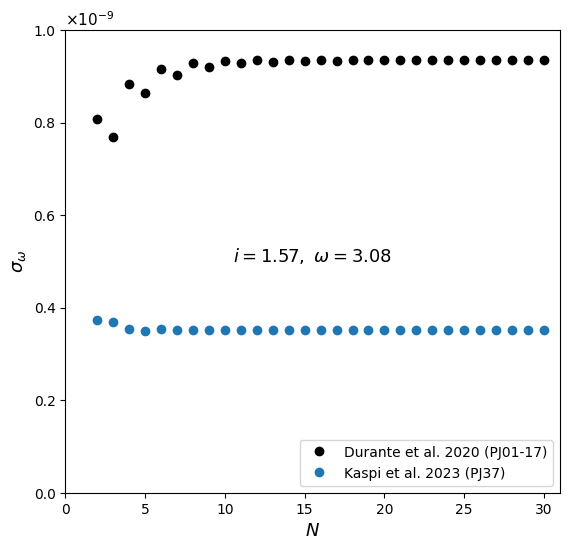

  N   old (Durante)    new (PJ37)   old/new
  2      8.0667e-10    3.7435e-10      2.15
  3      7.6820e-10    3.6939e-10      2.08
  4      8.8393e-10    3.5336e-10      2.50
  5      8.6436e-10    3.4945e-10      2.47
  6      9.1642e-10    3.5334e-10      2.59
  7      9.0350e-10    3.5060e-10      2.58
  8      9.2874e-10    3.5260e-10      2.63
  9      9.2062e-10    3.5164e-10      2.62
 10      9.3320e-10    3.5226e-10      2.65
 11      9.2840e-10    3.5209e-10      2.64
 12      9.3447e-10    3.5214e-10      2.65
 13      9.3189e-10    3.5213e-10      2.65
 14      9.3463e-10    3.5213e-10      2.65
 15      9.3340e-10    3.5213e-10      2.65
 16      9.3451e-10    3.5213e-10      2.65
 17      9.3401e-10    3.5213e-10      2.65
 18      9.3440e-10    3.5213e-10      2.65
 19      9.3423e-10    3.5213e-10      2.65
 20      9.3434e-10    3.5213e-10      2.65
 21      9.3430e-10    3.5213e-10      2.65
 22      9.3432e-10    3.5213e-10      2.65
 23      9.3431e-10    3.5213e-1

In [13]:
N = np.arange(2, 31)
sig_old = np.array([sigma_omega_N(n) for n in N]) # Durante
sig_new = np.array([sigma_omega_N_new(n) for n in N]) # Kaspi

fig, ax = plt.subplots(figsize=(5.8, 5.6))
ax.plot(N, sig_old / 1e-9, "o", color="k",       ms=6, label="Durante et al. 2020 (PJ01-17)")
ax.plot(N, sig_new / 1e-9, "o", color="#1f77b4", ms=6, label="Kaspi et al. 2023 (PJ37)")
ax.set_xlim(0, 31)
ax.set_ylim(0.0, 1.00)
ax.set_xlabel(r"$N$", fontsize=13)
ax.set_ylabel(r"$\sigma_\omega$", fontsize=13)
ax.text(0.5, 0.50, rf"$i = {INC},\ \omega = {OMEGA}$",
        transform=ax.transAxes, ha="center", fontsize=13)
ax.text(0.0, 1.01, r"$\times 10^{-9}$", transform=ax.transAxes, fontsize=11)
ax.legend(loc="lower right", frameon=True)
fig.tight_layout()
plt.show()

print(f"{'N':>3} {'old (Durante)':>15} {'new (PJ37)':>13} {'old/new':>9}")
for n, so, sn in zip(N, sig_old, sig_new):
    print(f"{n:>3} {so:15.4e} {sn:13.4e} {so/sn:9.2f}")
print(f"\nplateau (N>=12): old = {sig_old[N>=12].mean():.4e}, "
      f"new = {sig_new[N>=12].mean():.4e}, improvement = "
      f"{sig_old[N>=12].mean()/sig_new[N>=12].mean():.2f}x")

## Normalization / σ-level check of the covariance matrices vs the published tables

Repeat, for the **Kaspi et al. (2023)** PJ37 covariance, the exercise done by hand on the
Durante et al. (2020) supplement.

**Durante finding (the control).** For Durante's Table 2 (whose entries the collaborator reads
as **3σ**), squaring the tabulated value and dividing by the covariance diagonal gives exactly
`2l+1`:

```
(3σ_table)²  /  C_ll  =  2l+1     ⇔     C_ll = (3σ_table)² / (2l+1)
```

e.g. `J2: (1.7e-9)² / 5.703e-19 = 5.07 ≈ 5`, `J3: (3.3e-9)² / 9.162e-18 = 7.1 ≈ 7`.
So the Durante covariance is stored for the **fully-normalised** coefficient
`J̄_l = J_l/√(2l+1)`, at a scale where its implied *un-normalised* 1σ,
`s_cov(l) ≡ √((2l+1)·C_ll)`, equals the table's **3σ** value.

**Claim to test for Kaspi (Extended Data Table 1).** The covariance is "at 1σ, with
`J̄_l = J_l/√(2l+1)`". That would mean `s_cov(l) = √((2l+1)·C_ll)` equals the table's
**1σ** (and would equal 3× the table if it were really a 3σ matrix). We compute the ratio
`s_cov(l)/σ_table(l)` for every `l` and try both interpretations.


In [14]:
# Published low-degree uncertainties (dimensionless)
# Durante 2020, Table 2 ("Uncertainty (x1e-6)", quoted as 3*sigma) for J2..J10:
DURANTE_TABLE = {l: u * 1e-6 for l, u in {
    2: 0.0017, 3: 0.0033, 4: 0.0024, 5: 0.0042, 6: 0.0067,
    7: 0.012, 8: 0.021, 9: 0.036, 10: 0.065}.items()}
# Kaspi 2023, Extended Data Table 1 -- "Uncertainty (x1e-6)" column:
KASPI_TABLE = {l: u * 1e-6 for l, u in {
    2: 0.00163, 3: 0.00263, 4: 0.00213, 5: 0.00253, 6: 0.00203,
    7: 0.00249, 8: 0.00209, 9: 0.00257, 10: 0.00295}.items()}

def norm_check(name, C, table):
    """C is a [GM, J2..J10] block; table maps l -> published uncertainty.

    Four hypotheses are tested = {basis} x {sigma-level}. The covariance's implied
    un-normalised 1sigma on J_l is s_cov = sqrt((2l+1)*C_ll) in the fully-normalised
    ('norm', same as Durante) basis, or s_raw = sqrt(C_ll) if the matrix were already
    un-normalised ('other' basis). A hypothesis holds only if its column is a CONSTANT:
      value ~ 1  -> matrix is at 1 sigma in that basis
      value ~ 3  -> matrix is at 3 sigma in that basis
    """
    print(f"{name}")
    print(f"{'l':>3} {'2l+1':>5} {'s_cov':>10} {'s_raw':>10} {'σ_tab':>10}"
          f" | {'norm/1σ':>8} {'norm/3σ':>8} | {'other/1σ':>9} {'other/3σ':>9}")
    cols = {"norm/1σ": [], "norm/3σ": [], "other/1σ": [], "other/3σ": []}
    for l in sorted(table):
        Cll = C[l - 1, l - 1]
        s_cov = np.sqrt((2 * l + 1) * Cll)   # fully-normalised (Durante) basis
        s_raw = np.sqrt(Cll)                 # other (already un-normalised) basis
        s = table[l]
        v = {"norm/1σ": s_cov / s, "norm/3σ": s_cov / (3 * s),
             "other/1σ": s_raw / s, "other/3σ": s_raw / (3 * s)}
        for k in cols:
            cols[k].append(v[k])
        print(f"{l:>3} {2*l+1:>5} {s_cov:>10.3e} {s_raw:>10.3e} {s:>10.3e}"
              f" | {v['norm/1σ']:>8.3f} {v['norm/3σ']:>8.3f} |"
              f" {v['other/1σ']:>9.3f} {v['other/3σ']:>9.3f}")
    print("    hypothesis holds if its column is constant (≈1 ⇒ that basis & σ-level):")
    for k, val in cols.items():
        val = np.array(val)
        flag = "  <-- FLAT" if val.max() / val.min() < 1.10 else ""
        print(f"      {k:>9}: mean={val.mean():.3f}, "
              f"range=[{val.min():.3f}, {val.max():.3f}], "
              f"max/min={val.max()/val.min():.2f}{flag}")
    print()

norm_check("DURANTE 2020 (control; table read as 3σ)", COV_GM_J, DURANTE_TABLE)
norm_check("KASPI 2023 (claim: 1σ, J/√(2l+1))", COV_GM_J_NEW, KASPI_TABLE)


DURANTE 2020 (control; table read as 3σ)
  l  2l+1      s_cov      s_raw      σ_tab |  norm/1σ  norm/3σ |  other/1σ  other/3σ
  2     5  1.689e-09  7.552e-10  1.700e-09 |    0.993    0.331 |     0.444     0.148
  3     7  3.284e-09  1.241e-09  3.300e-09 |    0.995    0.332 |     0.376     0.125
  4     9  2.402e-09  8.007e-10  2.400e-09 |    1.001    0.334 |     0.334     0.111
  5    11  4.214e-09  1.270e-09  4.200e-09 |    1.003    0.334 |     0.302     0.101
  6    13  6.666e-09  1.849e-09  6.700e-09 |    0.995    0.332 |     0.276     0.092
  7    15  1.172e-08  3.027e-09  1.200e-08 |    0.977    0.326 |     0.252     0.084
  8    17  2.073e-08  5.029e-09  2.100e-08 |    0.987    0.329 |     0.239     0.080
  9    19  3.629e-08  8.326e-09  3.600e-08 |    1.008    0.336 |     0.231     0.077
 10    21  6.482e-08  1.415e-08  6.500e-08 |    0.997    0.332 |     0.218     0.073
    hypothesis holds if its column is constant (≈1 ⇒ that basis & σ-level):
        norm/1σ: mean=0.995, rang

## Basis resolution with the re-derived covariance (`cov_220824_base_a4_n40`)

The earlier Kaspi PJ37 slice (`COV_GM_J_NEW`) could not be pinned to a consistent basis:
in the check above *none* of the four {basis}x{sigma-level} columns comes out flat, so we
could not say whether its numbers refer to the coefficient `J_l` or to the fully-normalised
`J_l/sqrt(2l+1)`, nor at what sigma-level. The re-derived covariance
`cov_220824_base_a4_n40.txt` (zonal block `J2..J40`, no GM) is loaded here to settle that
question and re-run the pipeline on a matrix whose basis is known.


In [ ]:
import re

# Embedded verbatim contents of cov_220824_base_a4_n40.txt so this notebook is
# self-contained (zonal covariance block J2..J40, lower-triangular, no GM). No
# external .txt upload is needed -- the data below is a direct transcription.
COV_220824_TEXT = """\
Parameters:
J2
J3
J4
J5
J6
J7
J8
J9
J10
J11
J12
J13
J14
J15
J16
J17
J18
J19
J20
J21
J22
J23
J24
J25
J26
J27
J28
J29
J30
J31
J32
J33
J34
J35
J36
J37
J38
J39
J40

Lower triangular matrix of the covariance matrix:

 2.65073295633928e-18,
-1.20198601948538e-18,  6.90168875205213e-18,
-1.86682003496067e-19, -1.89693324175954e-18,  4.55635607370919e-18,
-8.09145385161746e-19,  2.64991268501016e-18, -1.73741634697318e-18,  6.42483378047241e-18,
 3.05020430175858e-19, -7.83826412556205e-19,  1.45920684275299e-18, -1.99566232914668e-18,  4.10200440232378e-18,
-3.05948857479182e-19,  1.12026938415928e-18, -9.09142010742586e-19,  2.59405486460683e-18, -2.70134081724177e-18,  6.22008098400134e-18,
 8.07905415857917e-20, -3.45238717732625e-19,  4.70889672109889e-19, -8.58279992820597e-19,  1.75979073220771e-18, -2.70407004215991e-18,  4.35983037891994e-18,
-9.07869883195253e-20,  3.95039707091289e-19, -4.34624176150115e-19,  9.70742259639678e-19, -1.66543429768047e-18,  3.20904399083703e-18, -4.57007438312641e-18,  6.62200329378745e-18,
 3.76547698906847e-20, -2.75087625319873e-19,  3.91096768458443e-19, -7.28360119855086e-19,  1.53376151075488e-18, -2.70626455634261e-18,  4.78347720656260e-18, -6.44284307475943e-18,  8.71915807548655e-18,
-3.77809786141893e-20,  1.97268194950348e-19, -2.38406333543235e-19,  5.23040412920858e-19, -1.01505844318039e-18,  2.07550951423401e-18, -3.57717674460984e-18,  5.79522679560078e-18, -7.81118793837329e-18,  9.27936872115529e-18,
-2.05043761415824e-20, -1.08945587990741e-21,  5.43841084959321e-20, -8.81934100490955e-20,  3.46936328354604e-19, -7.22892963734397e-19,  1.84247253696997e-18, -3.32299522676789e-18,  5.96286540105863e-18, -8.04582044998452e-18,  9.46230233010352e-18,
 1.38595838588013e-20, -8.79221495652209e-20,  1.20566569205392e-19, -2.27681639338378e-19,  4.04125474979524e-19, -5.42312350001214e-19,  5.30576176524329e-19,  1.71134577847496e-19, -1.72068316225215e-18,  4.63169694616557e-18, -7.16365140785137e-18,  8.90368716310736e-18,
-5.16659660908870e-20,  2.03773586200852e-19, -2.22879468473385e-19,  4.93818196241119e-19, -8.40965162360357e-19,  1.60625010785147e-18, -2.27469666247762e-18,  3.06765785493637e-18, -2.52728007963276e-18,  9.12400823618975e-19,  3.15652894589671e-18, -6.92484601856551e-18,  1.04892525694631e-17,
 1.75484685278181e-20, -1.69736474663851e-19,  2.43212439622171e-19, -4.80452182956112e-19,  1.01769672248238e-18, -1.89045799710051e-18,  3.36058775267526e-18, -4.89720822012242e-18,  6.42633157961072e-18, -5.95930890676216e-18,  3.65453450461648e-18,  2.58407362583262e-18, -8.93881949559435e-18,  1.49944589781153e-17,
-2.95390466793719e-20,  1.30865804590991e-19, -1.51587477154790e-19,  3.43806182396698e-19, -6.83819756229824e-19,  1.51725578002906e-18, -2.77806212230727e-18,  4.88319191734857e-18, -7.08929610594423e-18,  9.06875125988670e-18, -8.24374138515656e-18,  4.43883626270757e-18,  4.45771772430841e-18, -1.36879743551795e-17,  2.12815465023611e-17,
-1.03647273622529e-20, -1.46162984106789e-20,  3.58277501929315e-20, -5.94143976656422e-20,  2.53199136169126e-19, -5.79679031479777e-19,  1.52986276582454e-18, -2.96356095653039e-18,  5.59553063778742e-18, -8.23799638931090e-18,  1.07089448037919e-17, -9.18517039498449e-18,  3.96663420036487e-18,  7.84776127930852e-18, -1.89250997247974e-17,  2.69101065169759e-17,
 3.97365313000283e-21, -6.07503120261614e-20,  9.42618200561889e-20, -1.68153148260869e-19,  3.21974701708893e-19, -4.16391052674328e-19,  4.71543873980626e-19,  1.12064809167560e-19, -1.39820891367790e-18,  4.35654898182698e-18, -7.52947839442985e-18,  1.08411874127229e-17, -9.52682330991327e-18,  3.88707988466950e-18,  9.27680185325928e-18, -2.08700051447120e-17,  2.79261038873607e-17,
-2.16458281290464e-20,  9.11383152228782e-20, -1.09833999232943e-19,  2.44575137289149e-19, -4.45262986222054e-19,  9.01802798852175e-19, -1.40989703199434e-18,  2.07119771743794e-18, -2.08757283056341e-18,  1.23514344308950e-18,  1.84739667857756e-18, -5.88231396945666e-18,  1.08158604603136e-17, -1.12797100803788e-17,  6.89651173819391e-18,  6.20660756400151e-18, -1.85946157095043e-17,  2.66602839349980e-17,
 3.80651010940773e-21, -5.69485062534567e-20,  7.38009400155707e-20, -1.43774003697069e-19,  3.63195030731945e-19, -7.60490262532302e-19,  1.57528595129865e-18, -2.67210342554254e-18,  4.20118177234938e-18, -5.10691271946497e-18,  4.90208698463353e-18, -1.22880617209297e-18, -4.81743337684802e-18,  1.33982323812071e-17, -1.72475795119860e-17,  1.46001287413826e-17,  7.27774410818369e-19, -1.77625905372699e-17,  3.10744944110530e-17,
 3.39844574720539e-21, -1.75603712017738e-20,  2.65692196261094e-20, -3.91195767096600e-20,  1.95688704888952e-20,  1.33248859360991e-19, -5.46888946627546e-19,  1.53458882015876e-18, -3.22778228788058e-18,  5.69362161271978e-18, -7.60433917891170e-18,  7.68182647526446e-18, -2.91681126335507e-18, -6.14110267097147e-18,  1.84557426961213e-17, -2.47245060279795e-17,  2.06891405133919e-17,  1.14122350723898e-19, -2.38125107060844e-17,  4.02400880141805e-17,
-4.49080392739620e-21,  3.67993101406515e-20, -5.94551555478120e-20,  1.12546032828692e-19, -1.95703378501043e-19,  2.91720250850557e-19, -2.83125498344637e-19, -5.42615731595596e-20,  1.07506160396009e-18, -3.11094394361229e-18,  5.92122976098865e-18, -8.29701206547559e-18,  8.15091576453701e-18, -2.70541775401300e-18, -7.95280860781685e-18,  2.12077830046782e-17, -2.72342546783566e-17,  2.04486928501235e-17,  3.93870337085379e-18, -2.95621035757702e-17,  4.39108698008900e-17,
 8.81335347630000e-21, -3.02792562164288e-20,  2.36125102699442e-20, -5.55410304346073e-20,  1.10344849136386e-19, -2.57226643857971e-19,  4.32383905252833e-19, -6.72367052400766e-19,  6.89695830360400e-19, -3.04789434138935e-19, -1.14144887488621e-18,  3.59813234995187e-18, -6.62490931291309e-18,  7.96448567527522e-18, -4.78557499172363e-18, -4.32361827289340e-18,  1.74620714516161e-17, -2.52779605885321e-17,  2.09812900736944e-17,  1.76433468587526e-18, -2.72507382597386e-17,  4.25638591971467e-17,
 1.48073190039182e-20, -4.83521604228327e-20,  5.63332825583173e-20, -1.20643627278975e-19,  1.59106832150843e-19, -2.44133580841075e-19,  1.57980590299361e-19,  6.20984284670146e-20, -8.37952333070900e-19,  1.85889198328178e-18, -2.96614777577722e-18,  2.43053324179122e-18,  1.99017656768499e-19, -5.85662426603090e-18,  1.10362873185165e-17, -1.17141113181106e-17,  2.86342901758274e-18,  1.40369728221972e-17, -2.85259608876316e-17,  2.87421529888180e-17, -4.82698566232887e-18, -2.69037507388856e-17,  4.83467396735804e-17,
-4.42213267798941e-21,  7.16780150698059e-20, -1.14156568002519e-19,  2.08586739129208e-19, -4.18201405253787e-19,  6.70628632738729e-19, -1.02925017918697e-18,  1.05000966780676e-18, -6.77238673275375e-19, -9.96125542131492e-19,  3.02841394834803e-18, -5.56394537653055e-18,  5.13208236958229e-18, -1.62689834332310e-18, -7.29926446641461e-18,  1.51667678183992e-17, -1.75862750991011e-17,  5.82359158008156e-18,  1.59439017088283e-17, -3.52325654898724e-17,  3.50756216785145e-17, -4.95729402870341e-18, -3.28136534468807e-17,  5.63416836217937e-17,
 1.64444481565300e-20, -5.93056476843924e-20,  6.03047677874131e-20, -1.38181532342346e-19,  2.49256020880720e-19, -5.45228282027509e-19,  8.49002511121309e-19, -1.32262144383829e-18,  1.41245267769775e-18, -1.15417902062006e-18, -4.84538844247907e-19,  2.56895973027729e-18, -5.53792367559993e-18,  5.71485054406826e-18, -2.94273122762601e-18, -5.82509679201298e-18,  1.41651660052796e-17, -1.77424800578325e-17,  6.90775934102801e-18,  1.45154932290551e-17, -3.43363906871451e-17,  3.45276176982133e-17, -5.04207289763478e-18, -3.28941488603544e-17,  5.49854996904833e-17,
 7.71945678050022e-21, -9.77439724194510e-21,  1.27719684633844e-20, -3.56612755841354e-20, -2.27409221856454e-21,  3.80718988405956e-20, -2.67591363333764e-19,  5.83562376711225e-19, -1.34082941566464e-18,  2.07142596644336e-18, -2.89656482906525e-18,  1.93843128290992e-18,  2.37678009812092e-19, -5.19805334241240e-18,  8.29863043980861e-18, -8.56619513349746e-18, -2.27157424337319e-19,  1.17732551923539e-17, -2.13309021179366e-17,  1.42339193185411e-17,  8.23546909019396e-18, -3.42798359013544e-17,  4.04739745154163e-17, -1.13409554361700e-17, -3.23068549775371e-17,  6.08249186078779e-17,
-4.72125953806479e-21,  6.58065147301273e-20, -9.99711078140471e-20,  1.75634807090242e-19, -3.51003848202184e-19,  5.56980456425985e-19, -8.46267970089745e-19,  8.37464573944916e-19, -4.95263754747241e-19, -9.97947221580614e-19,  2.75041172528512e-18, -5.00133584952345e-18,  4.48431375265814e-18, -1.63089059348888e-18, -6.20371675629001e-18,  1.20257115701622e-17, -1.40461819768034e-17,  2.57545083238438e-18,  1.37765667661671e-17, -2.83315917182525e-17,  2.09012122200967e-17,  7.73735168751384e-18, -4.03722379453508e-17,  4.91094672309292e-17, -1.18656165514846e-17, -3.82278802660275e-17,  6.98480085222205e-17,
 6.52673771164157e-21, -4.13899552692829e-20,  5.61354085532509e-20, -1.12346997603842e-19,  2.30468381611276e-19, -4.71739930531115e-19,  7.88145531768608e-19, -1.15719519355000e-18,  1.32599752492824e-18, -9.92520037935621e-19, -3.60395328324501e-19,  2.38823597699711e-18, -4.83444280620125e-18,  5.15317663909162e-18, -2.62497661542673e-18, -4.65792174448712e-18,  1.11470465371180e-17, -1.37572844263367e-17,  3.44159438313870e-18,  1.23521431031470e-17, -2.71797294346443e-17,  1.97649838373897e-17,  6.82988536220372e-18, -3.97633612948220e-17,  4.61088127029769e-17, -1.23358807953853e-17, -3.67773092976492e-17,  6.36762140305435e-17,
-1.82195301546189e-21,  2.01781571190838e-21,  1.38537133683797e-20, -1.91548505229742e-20,  6.85641354153932e-21,  6.07008125888117e-20, -2.23234211375269e-19,  5.85668043087510e-19, -1.19005885768066e-18,  2.01342966177381e-18, -2.59605569192825e-18,  2.04025192025498e-18,  1.89602051541033e-19, -4.28030778690445e-18,  7.66237947110814e-18, -7.98012006500682e-18,  1.23982607329250e-18,  8.44420850181022e-18, -1.69451479259489e-17,  1.11327701229381e-17,  5.11333124282457e-18, -2.64697536994347e-17,  2.63086268344979e-17, -1.70405776228632e-18, -3.73082877190973e-17,  5.27010065291169e-17, -2.16438507765598e-17, -3.33129852131880e-17,  7.05682062011942e-17,
-1.11179462577414e-20,  6.20286134751161e-20, -8.07670055741860e-20,  1.53766903846523e-19, -2.69536960170194e-19,  4.63335109455929e-19, -6.31505570619960e-19,  6.45797718483423e-19, -1.95211811222404e-19, -1.01462912275650e-18,  2.80597913215459e-18, -4.45063648287413e-18,  4.28395523051215e-18, -1.12159951700050e-18, -5.41877483285317e-18,  1.14228590615971e-17, -1.28550474983600e-17,  3.69175937234332e-18,  1.07001730320733e-17, -2.33888652282398e-17,  1.70080992664082e-17,  5.27588232034435e-18, -3.26320596261865e-17,  3.42775041777274e-17, -1.57913139165628e-18, -4.34177037798063e-17,  6.11869996966096e-17, -1.88645532265113e-17, -4.32538331244244e-17,  7.88278567360264e-17,
-2.38148196987914e-21, -3.14093325792740e-20,  5.62268883062724e-20, -9.06672557163885e-20,  2.27711151376182e-19, -4.03030051280988e-19,  7.33847720994988e-19, -9.55377290208773e-19,  1.16927777801343e-18, -6.20948508365096e-19, -3.80971026730541e-19,  2.56880613363011e-18, -4.15914759062856e-18,  4.85374861696865e-18, -1.59067231820151e-18, -4.10342624930539e-18,  1.08428811248164e-17, -1.20606215122241e-17,  4.09795838305458e-18,  9.85009360725268e-18, -2.20906242788590e-17,  1.51927107801976e-17,  4.71716714217355e-18, -3.22923397382671e-17,  3.03008893716047e-17, -2.14622537357284e-18, -4.19651988163729e-17,  5.37748138789191e-17, -1.47679763931731e-17, -3.96942348844813e-17,  7.00216309521279e-17,
-5.47210974348294e-21, -3.53562183979018e-21,  2.51714768169644e-20, -2.91517565417461e-20,  5.76770683800494e-20, -6.67810934991193e-21, -3.66153963612908e-20,  3.49263850548388e-19, -7.36672490215985e-19,  1.57296365258252e-18, -1.91183016297396e-18,  1.88431044249963e-18,  2.23726374640787e-19, -3.00069297891077e-18,  6.56981991173583e-18, -6.22628239512311e-18,  1.88654147658024e-18,  7.38955208643876e-18, -1.40276287398209e-17,  1.15520520955132e-17,  1.78902039100272e-18, -1.96290661341322e-17,  2.13278241263489e-17, -5.29224238902193e-18, -2.71150862907737e-17,  3.62762608718884e-17, -1.43931396649858e-17, -3.38442647036112e-17,  5.92707883207229e-17, -2.92185435409079e-17, -2.85912829274146e-17,  7.22112617176677e-17,
-8.18354304077223e-21,  4.03757709275929e-20, -5.35122644392753e-20,  1.02466059828606e-19, -1.71810089653681e-19,  3.05273264785649e-19, -3.77397555134581e-19,  3.71584412080085e-19,  4.73640247742269e-20, -9.37711032868214e-19,  2.40966051116502e-18, -3.44701479471466e-18,  3.40831599642103e-18, -5.02175450859074e-19, -4.26897866487324e-18,  9.52301913240736e-18, -9.83596563884089e-18,  3.42972522934685e-18,  9.14651417250401e-18, -1.82364681906748e-17,  1.50143272538674e-17,  3.18791415449114e-18, -2.37895302684162e-17,  2.63738009110299e-17, -2.70377024767847e-18, -3.15246526244905e-17,  4.12168720940120e-17, -8.37402038985584e-18, -4.32386271980247e-17,  6.39442997222370e-17, -2.35332641323157e-17, -4.26097131534491e-17,  7.23732366613637e-17,
-2.46212638780709e-21, -2.35220540752340e-20,  4.09406243238770e-20, -5.75977817707219e-20,  1.53321896246104e-19, -2.61825895868092e-19,  4.77841665356199e-19, -5.68220642497998e-19,  6.79371928845529e-19, -1.66109004201161e-19, -5.46933854865084e-19,  2.22774773340769e-18, -3.10426289455764e-18,  3.58337977557779e-18, -5.78383509634564e-19, -3.36911597682654e-18,  8.90662385340647e-18, -8.75050626748316e-18,  3.47932023821341e-18,  8.29041146428641e-18, -1.62790205286743e-17,  1.26167441036307e-17,  2.90039098917583e-18, -2.26454544861238e-17,  2.15949100435891e-17, -3.13516096494877e-18, -2.92208989275719e-17,  3.24771587277764e-17, -4.24569537383147e-18, -3.91630682517862e-17,  5.40635667337522e-17, -1.20113202054988e-17, -3.73161746692165e-17,  6.36084404121521e-17,
 2.82818123512317e-22, -1.79088184347839e-20,  3.03807871916786e-20, -4.75774970970488e-20,  8.78552657631185e-20, -1.04126242673642e-19,  1.28263823063209e-19, -7.93678299478629e-21, -1.96271221593870e-19,  7.23861411589048e-19, -9.81082431883539e-19,  1.06046780715295e-18,  2.36919214843356e-19, -1.89231940544176e-18,  4.27791608770022e-18, -3.76562042122166e-18,  1.11466363501751e-18,  5.73039998758281e-18, -9.55381216052461e-18,  8.82437474920298e-18,  1.81778050760785e-18, -1.32773394271140e-17,  1.67781633062936e-17, -4.85808371749838e-18, -1.72853204557812e-17,  2.55307429316518e-17, -1.32729658443500e-17, -2.09953414772636e-17,  3.52149203396246e-17, -1.70791520715979e-17, -2.72544541616791e-17,  5.21117595438470e-17, -2.26032615182081e-17, -2.59223414565629e-17,  5.87849451090657e-17,
 9.26763682148414e-22,  1.92271003713164e-20, -3.90979247328420e-20,  5.79042260870461e-20, -1.19749180987275e-19,  1.91822152280543e-19, -2.79529498830923e-19,  2.43958386469401e-19, -8.14504617970937e-20, -5.18219611343617e-19,  1.25935121831475e-18, -1.99756517631379e-18,  1.72183996755439e-18, -1.53688950537377e-19, -2.94662741764506e-18,  5.70667284266360e-18, -5.76198630997799e-18,  1.51216267612643e-18,  6.41447241611655e-18, -1.10472292747610e-17,  9.47749420834255e-18,  3.86175947443268e-18, -1.43774326012790e-17,  1.81697823650137e-17, -6.64220567151794e-20, -1.85527451386394e-17,  2.61760769785929e-17, -4.86151120113552e-18, -2.74645300539891e-17,  3.47977404660253e-17, -1.12385145915554e-17, -3.66673910548698e-17,  4.46090343943823e-17, -1.68680418421147e-17, -3.07395773986390e-17,  4.28028837871845e-17,
-5.70761445618032e-22, -7.81909803375610e-21,  1.15549662108706e-20, -1.03297073014397e-20,  3.27427111849450e-20, -6.33462042115557e-20,  9.96475678571648e-20, -1.05302316393856e-19,  9.08378596871096e-20,  1.07332609654850e-19, -4.11448658486809e-19,  9.47248629762540e-19, -1.19432157945607e-18,  1.09657372264740e-18,  2.66380727505601e-19, -2.03385888196508e-18,  4.18813550300363e-18, -3.78496492623251e-18,  1.42258690670193e-18,  3.96507133985164e-18, -6.70430979128275e-18,  5.56257131095099e-18,  2.13972444207099e-18, -9.58780639424226e-18,  1.01299669028444e-17, -1.62266192007381e-18, -1.14533504897503e-17,  1.23077149101383e-17, -1.33744282997043e-18, -1.79428243115257e-17,  2.03164713495907e-17, -2.09122824430488e-18, -2.23204619810214e-17,  3.13628677711574e-17, -9.89849463968363e-18, -1.20717030924686e-17,  2.14624590850377e-17,
 3.87439415570112e-21, -1.73665372068368e-20,  2.05727631847314e-20, -4.04841240544106e-20,  6.55087423164809e-20, -1.16614898350700e-19,  1.56162740845175e-19, -1.85713453627603e-19,  1.25822445333018e-19,  2.29864129378428e-20, -2.23482188537437e-19,  2.79931239901416e-19, -4.94046715639736e-20, -5.22245172347316e-19,  1.11806378573618e-18, -9.67403775319310e-19, -2.12944119735407e-19,  2.63279906432485e-18, -3.90048192494698e-18,  3.43845220101950e-18,  1.23627400835048e-18, -5.16890131237807e-18,  7.09243823495599e-18, -9.02215866132437e-19, -7.06767726459864e-18,  1.17277315392620e-17, -5.88078900028486e-18, -7.45928842741201e-18,  1.28782602264356e-17, -6.79609434522623e-18, -1.24235579099412e-17,  1.80963784874930e-17, -5.74273498912125e-18, -1.80024416943445e-17,  2.88803427285683e-17, -1.08954795894918e-17, -9.86329448422618e-18,  2.09574368265514e-17,
 2.59660537580519e-21,  1.30344358176308e-20, -2.82116695001191e-20,  3.54873696092545e-20, -8.91549350046462e-20,  1.43500234202454e-19, -2.38916338364729e-19,  2.62088684722806e-19, -2.91983661439784e-19,  2.45446745740249e-20,  2.07946316974781e-19, -7.08851691016666e-19,  6.12382173792082e-19, -4.11057852914444e-19, -8.26906983179818e-19,  1.45881610678012e-18, -1.76641050809429e-18, -6.21210114216425e-20,  2.56732771418692e-18, -4.14446724006542e-18,  3.36060164583755e-18,  2.11734202694909e-18, -5.04886654539083e-18,  7.19726828225225e-18,  1.71315098319096e-18, -7.04154721076797e-18,  1.16602751891253e-17, -1.78193781738514e-18, -9.67638528045737e-18,  1.19969546560498e-17, -4.73470142845109e-18, -1.53648547670169e-17,  1.24608828462477e-17, -3.17191696427963e-18, -1.90527560027111e-17,  1.93579682429052e-17, -1.02312517654349e-18, -9.88275546989352e-18,  1.61149539054209e-17,
"""

def load_cov_220824(text=COV_220824_TEXT):
    """Parse the embedded dump (a `Parameters` list + a lower-triangular numeric
    block). Returns (labels, C) with labels = ['J2', ..., 'J40'] and C the
    symmetric covariance matrix.
    """
    head, body = text.split("Lower triangular matrix of the covariance matrix:")
    labels = re.findall(r"J\d+", head)
    rows = []
    for line in body.splitlines():
        line = line.strip().rstrip(",")
        if line:
            rows.append([float(x) for x in line.split(",") if x.strip()])
    n = len(rows)
    M = np.zeros((n, n))
    for i, r in enumerate(rows):
        for j, v in enumerate(r):
            M[i, j] = M[j, i] = v
    return labels, M

LABELS_NEW2, COV_J40_NEW2 = load_cov_220824()
_ev = np.linalg.eigvalsh(COV_J40_NEW2)
print(f"loaded {COV_J40_NEW2.shape} block: {LABELS_NEW2[0]}..{LABELS_NEW2[-1]}"
      f"  (positive-definite: {_ev.min() > 0}, cond = {_ev.max() / _ev.min():.1e})")
print("diag sqrt(C_ll) for J2..J10  (raw-basis 1-sigma on J_l):")
print("  " + ", ".join(f"{np.sqrt(COV_J40_NEW2[l - 2, l - 2]):.3e}" for l in range(2, 11)))


In [16]:
def basis_check_J(name, Cblock, table, l_to_index):
    """4-hypothesis basis / sigma-level check for a zonal covariance block.

    l_to_index(l) -> row/col of J_l in Cblock. A column that is flat at ~1 identifies
    the basis (norm = J_l/sqrt(2l+1); raw = J_l) and the sigma-level of the stored matrix:
      value ~ 1  -> matrix is at 1 sigma in that basis
      value ~ 3  -> matrix is at 3 sigma in that basis
    """
    print(name)
    print(f"{'l':>3} {'s_cov':>10} {'s_raw':>10} {'sig_tab':>10}"
          f" | {'norm/1s':>8} {'norm/3s':>8} {'raw/1s':>8} {'raw/3s':>8}")
    cols = {"norm/1s": [], "norm/3s": [], "raw/1s": [], "raw/3s": []}
    for l in sorted(table):
        Cll = Cblock[l_to_index(l), l_to_index(l)]
        s_cov, s_raw, s = np.sqrt((2 * l + 1) * Cll), np.sqrt(Cll), table[l]
        v = {"norm/1s": s_cov / s, "norm/3s": s_cov / (3 * s),
             "raw/1s": s_raw / s, "raw/3s": s_raw / (3 * s)}
        for k in cols:
            cols[k].append(v[k])
        print(f"{l:>3} {s_cov:>10.3e} {s_raw:>10.3e} {s:>10.3e}"
              f" | {v['norm/1s']:>8.3f} {v['norm/3s']:>8.3f}"
              f" {v['raw/1s']:>8.3f} {v['raw/3s']:>8.3f}")
    for k, val in cols.items():
        val = np.array(val)
        flag = "  <-- FLAT" if val.max() / val.min() < 1.10 else ""
        print(f"    {k:>8}: mean={val.mean():.3f}, "
              f"range=[{val.min():.3f}, {val.max():.3f}], "
              f"max/min={val.max() / val.min():.2f}{flag}")
    print()

# new matrix: J_l sits at index l-2 (J2 -> 0). Old Kaspi slice: J_l at index l-1 (GM at 0).
basis_check_J("cov_220824_base_a4_n40  vs Kaspi Ext. Data Table 1",
              COV_J40_NEW2, KASPI_TABLE, lambda l: l - 2)
basis_check_J("cov_220824_base_a4_n40  vs Durante Table 2",
              COV_J40_NEW2, DURANTE_TABLE, lambda l: l - 2)
basis_check_J("(for contrast) old Kaspi PJ37 slice  vs Kaspi Ext. Data Table 1",
              COV_GM_J_NEW, KASPI_TABLE, lambda l: l - 1)


cov_220824_base_a4_n40  vs Kaspi Ext. Data Table 1
  l      s_cov      s_raw    sig_tab |  norm/1s  norm/3s   raw/1s   raw/3s
  2  3.641e-09  1.628e-09  1.630e-09 |    2.233    0.744    0.999    0.333
  3  6.951e-09  2.627e-09  2.630e-09 |    2.643    0.881    0.999    0.333
  4  6.404e-09  2.135e-09  2.130e-09 |    3.006    1.002    1.002    0.334
  5  8.407e-09  2.535e-09  2.530e-09 |    3.323    1.108    1.002    0.334
  6  7.302e-09  2.025e-09  2.030e-09 |    3.597    1.199    0.998    0.333
  7  9.659e-09  2.494e-09  2.490e-09 |    3.879    1.293    1.002    0.334
  8  8.609e-09  2.088e-09  2.090e-09 |    4.119    1.373    0.999    0.333
  9  1.122e-08  2.573e-09  2.570e-09 |    4.365    1.455    1.001    0.334
 10  1.353e-08  2.953e-09  2.950e-09 |    4.587    1.529    1.001    0.334
     norm/1s: mean=3.528, range=[2.233, 4.587], max/min=2.05
     norm/3s: mean=1.176, range=[0.744, 1.529], max/min=2.05
      raw/1s: mean=1.000, range=[0.998, 1.002], max/min=1.00  <-- FLAT
      

**Result.** For `cov_220824_base_a4_n40` the **`raw/1s` column is flat at ~1.000**
(`sqrt(C_ll)` reproduces the Kaspi Extended Data Table 1 uncertainties to <1%), whereas no
column of the old PJ37 slice is flat. The re-derived matrix is therefore stored for the
**un-normalised coefficient `J_l` itself, at 1 sigma** -- the basis ambiguity is resolved.

Its `sigma_omega` must therefore be formed with the **un-normalised** gradient
(`sqrt(2l+1)` factor OFF). For a fair comparison Durante -- whose control shows it is stored
for the **fully-normalised** `J_l/sqrt(2l+1)` -- is contracted with the **normalised**
gradient (`sqrt(2l+1)` ON). Each matrix is thus used in its own *verified* basis, which is
the only apples-to-apples comparison (GM is dropped throughout: its contribution to
`sigma_omega` is < 0.1%).


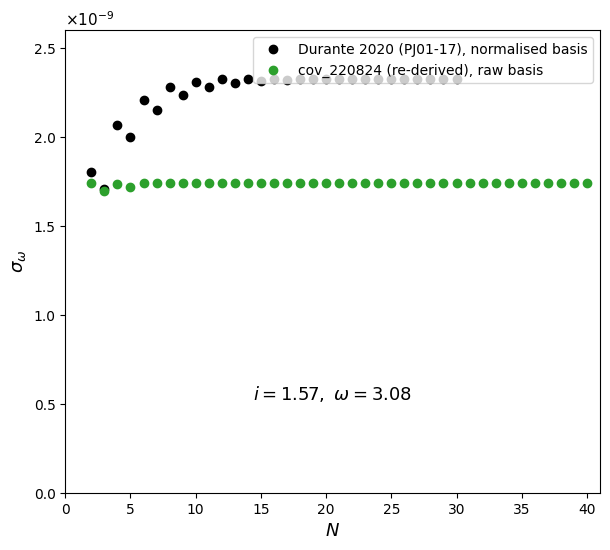

sigma_omega plateau  Durante (consistent) = 2.3233e-09
sigma_omega plateau  cov_220824 (raw 1s)  = 1.7402e-09
  basis-consistent improvement factor = 1.34x

note: the earlier in-notebook comparison contracted BOTH matrices with the raw
gradient; that understates Durante (its normalised numbers are ~sqrt(2l+1) too
small) and is only meaningful once every matrix sits in a *verified* basis.


In [17]:
def _grad_J_gauss(n_max, normalize):
    """[d/dJ2 ... d/dJ_nmax] from the Gauss model; normalize -> x sqrt(2l+1) (norm basis)."""
    return np.array([domega_dJl_gauss(l) * (np.sqrt(2 * l + 1) if normalize else 1.0)
                     for l in range(2, n_max + 1)])

def sigma_omega_N_new2(n_max):
    """sigma_omega from the re-derived matrix (raw J basis -> raw gradient), J2..J_nmax."""
    g = _grad_J_gauss(n_max, normalize=False)
    return float(np.sqrt(g @ COV_J40_NEW2[:n_max - 1, :n_max - 1] @ g))

def sigma_omega_N_dur_consistent(n_max):
    """sigma_omega from Durante in its own (fully-normalised) basis -> normalised gradient."""
    g = _grad_J_gauss(n_max, normalize=True)
    return float(np.sqrt(g @ COV_GM_J30[1:n_max, 1:n_max] @ g))   # drop GM (negligible)

N_new = np.arange(2, 41)   # the re-derived matrix reaches J40
N_dur = np.arange(2, 31)   # Durante block embedded above stops at J30
sig_new2 = np.array([sigma_omega_N_new2(n) for n in N_new])
sig_dur  = np.array([sigma_omega_N_dur_consistent(n) for n in N_dur])

fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.plot(N_dur, sig_dur / 1e-9, "o", color="k", ms=6,
        label="Durante 2020 (PJ01-17), normalised basis")
ax.plot(N_new, sig_new2 / 1e-9, "o", color="C2", ms=6,
        label="cov_220824 (re-derived), raw basis")
ax.set_xlim(0, 41)
ax.set_ylim(0.0, 2.6)
ax.set_xlabel(r"$N$", fontsize=13)
ax.set_ylabel(r"$\sigma_\omega$", fontsize=13)
ax.text(0.5, 0.20, rf"$i = {INC},\ \omega = {OMEGA}$",
        transform=ax.transAxes, ha="center", fontsize=13)
ax.text(0.0, 1.01, r"$\times 10^{-9}$", transform=ax.transAxes, fontsize=11)
ax.legend(loc="upper right", frameon=True)
fig.tight_layout()
plt.show()

new_plateau = sig_new2[N_new >= 4].mean()
dur_plateau = sig_dur[N_dur >= 12].mean()
print(f"sigma_omega plateau  Durante (consistent) = {dur_plateau:.4e}")
print(f"sigma_omega plateau  cov_220824 (raw 1s)  = {new_plateau:.4e}")
print(f"  basis-consistent improvement factor = {dur_plateau / new_plateau:.2f}x")
print()
print("note: the earlier in-notebook comparison contracted BOTH matrices with the raw")
print("gradient; that understates Durante (its normalised numbers are ~sqrt(2l+1) too")
print("small) and is only meaningful once every matrix sits in a *verified* basis.")


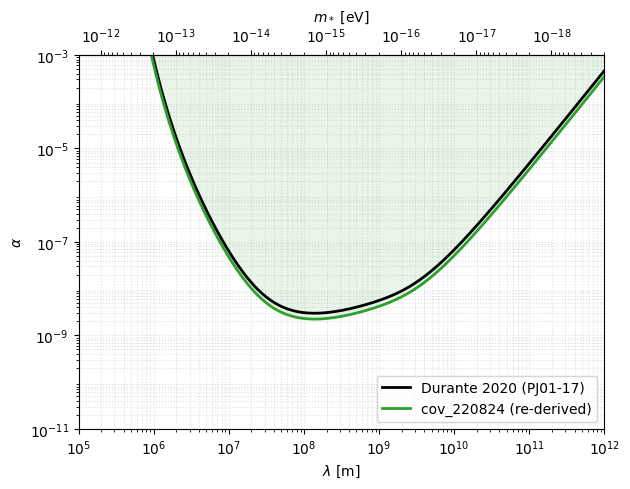

best bound Durante : alpha >~ 2.98e-09 at lambda = 1.35e+08 m
best bound new     : alpha >~ 2.23e-09 at lambda = 1.35e+08 m
  bound tightens by 1.34x


In [18]:
# Figure-4-style fifth-force bound with the basis-resolved sigma_omega (95% C.L. = 2 sigma).
lam = np.logspace(5, 12, 200)
g_abs = np.abs(g_finite_size(lam))
alpha_dur = 2.0 * dur_plateau / g_abs
alpha_new = 2.0 * new_plateau / g_abs

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.loglog(lam, alpha_dur, "k-", lw=2.0, label="Durante 2020 (PJ01-17)")
ax.loglog(lam, alpha_new, "C2-", lw=2.0, label="cov_220824 (re-derived)")
ax.fill_between(lam, alpha_new, 1e-3, color="C2", alpha=0.10)
style_log(ax, (1e5, 1e12), (1e-11, 1e-3), r"$\lambda$ [m]", r"$\alpha$",
          decades(5, 12), decades(-11, -3, 2))
add_mass_axis(ax, range(-12, -19, -1))
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

id_, in_ = int(np.argmin(alpha_dur)), int(np.argmin(alpha_new))
print(f"best bound Durante : alpha >~ {alpha_dur[id_]:.2e} at lambda = {lam[id_]:.2e} m")
print(f"best bound new     : alpha >~ {alpha_new[in_]:.2e} at lambda = {lam[in_]:.2e} m")
print(f"  bound tightens by {alpha_dur[id_] / alpha_new[in_]:.2f}x")


## Diagnostics: correlation structure, the GM term, and why `cov_220824` flattens so fast

The re-derived `cov_220824` curve above reaches its plateau almost immediately (by `N=4`),
whereas Durante climbs until `N~12`. That early saturation is surprising, so the three cells
below unpack it:

- **(c)** the *correlation* matrices of the two covariances (Durante `J2..J30`, `cov_220824`
  `J2..J40`), to compare their off-diagonal / banding patterns;
- **(d)** the contribution of **GM** alone to `sigma_omega`, to confirm dropping it is safe;
- a **per-degree budget** of `cov_220824`'s `sigma_omega(N)`, which is the actual driver of the
  fast flattening.


In [ ]:
# ---- CHECK (c): correlation structure of the two covariance matrices --------
def correlation(C):
    d = np.sqrt(np.diag(C))
    return C / np.outer(d, d)

# each matrix in its own verified basis; use the J-only blocks for a like-for-like
# comparison (Durante drops its GM row/col here)
R_dur = correlation(COV_GM_J30[1:, 1:])      # J2..J30 (normalised basis)
R_new = correlation(COV_J40_NEW2)            # J2..J40 (raw basis)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, R, title in [(axes[0], R_dur, "Durante 2020  (J2..J30, normalised)"),
                     (axes[1], R_new, "cov_220824  (J2..J40, raw)")]:
    im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("degree index  (0 = J2)")
    ax.set_ylabel("degree index  (0 = J2)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="correlation")
fig.tight_layout()
plt.show()

print("adjacent-degree correlation  corr(J_l, J_{l+1}):")
print(f"{'l':>3} {'Durante':>9} {'cov_220824':>11}")
for l in range(2, 30):
    print(f"{l:>3} {R_dur[l - 2, l - 1]:>9.3f} {R_new[l - 2, l - 1]:>11.3f}")

print("\nmean SIGNED correlation on off-diagonal band k (alternating-sign test):")
print(f"{'k':>3} {'Durante':>9} {'cov_220824':>11}")
for k in range(1, 6):
    print(f"{k:>3} {np.diagonal(R_dur, k).mean():>9.3f} {np.diagonal(R_new, k).mean():>11.3f}")


In [ ]:
# ---- CHECK (d): contribution to sigma_omega from GM alone -------------------
# cov_220824 has no GM row, so GM can only be probed with the matrices that carry it
# (Durante and the old Kaspi PJ37 slice). GM itself is not normalised, so its term is
# basis-independent; the J's use the fully-normalised gradient here.
gmu = domega_dmu(A_KM, ECC)                 # d<omega>/dmu, units (km^3 s^-2)^-1
print(f"d<omega>/dmu (leading GR term) = {gmu:.4e}  (km^3 s^-2)^-1\n")

for name, C, nmax in [("Durante   [GM, J2..J30]", COV_GM_J30, 30),
                      ("Kaspi PJ37 [GM, J2..J10]", COV_GM_J_NEW, 10)]:
    g = np.array([gmu] + [domega_dJl_gauss(l) * np.sqrt(2 * l + 1)
                          for l in range(2, nmax + 1)])
    var_full = float(g @ C @ g)                       # everything
    var_noGM = float(g[1:] @ C[1:, 1:] @ g[1:])       # J's only (drop GM row/col)
    var_gm   = g[0] ** 2 * C[0, 0]                     # GM diagonal term only
    s_full, s_noGM = np.sqrt(var_full), np.sqrt(var_noGM)
    print(name)
    print(f"  sqrt(Var[GM])                    = {np.sqrt(C[0, 0]):.4e}  (km^3 s^-2)")
    print(f"  sigma_omega  (all params)        = {s_full:.4e}")
    print(f"  sigma_omega  (J's only, GM drop) = {s_noGM:.4e}")
    print(f"  GM diagonal term                 = {np.sqrt(var_gm):.4e}"
          f"   ({var_gm / var_full * 100:.2e}% of the variance)")
    print(f"  net effect of dropping GM on sigma = "
          f"{(s_full - s_noGM) / s_full * 100:+.2e}%\n")


In [ ]:
# ---- Why cov_220824 flattens by N=4: per-degree budget of sigma_omega(N) ----
def sig_new(nmax):
    g = np.array([domega_dJl_gauss(l) for l in range(2, nmax + 1)])   # raw basis
    return float(np.sqrt(g @ COV_J40_NEW2[:nmax - 1, :nmax - 1] @ g))

print("per-degree diagonal budget  |g_l| * sqrt(C_ll)  vs  running sigma_omega:")
print(f"{'l':>3} {'|g_l|*sqrt(C_ll)/1e-9':>22} {'sigma(J2..Jl)/1e-9':>19} {'delta/1e-9':>12}")
prev = 0.0
for l in range(2, 13):
    s = sig_new(l)
    term = abs(domega_dJl_gauss(l)) * np.sqrt(COV_J40_NEW2[l - 2, l - 2])
    print(f"{l:>3} {term / 1e-9:>22.4f} {s / 1e-9:>19.4f} {(s - prev) / 1e-9:>12.4f}")
    prev = s

s2, s40 = sig_new(2), sig_new(40)
print(f"\nJ2 alone      -> {s2 / 1e-9:.4f}e-9")
print(f"full J2..J40  -> {s40 / 1e-9:.4f}e-9")
print(f"=> everything above J2 changes sigma_omega by only "
      f"{(s40 - s2) / s2 * 100:+.2f}%  (the plateau is essentially set by J2)")


### Interpretation

**(c) Correlation patterns.** Both matrices are strongly *anti*-correlated between neighbouring
degrees, but with different character:

- *Durante* is an almost perfectly **alternating-sign band** matrix: `corr(J_l, J_{l+1})` runs
  from `-0.45` up to `-0.99`, and the signed band means alternate cleanly (`k=1:-0.89`, `k=2:+0.90`,
  `k=3:-0.83`, ...). Because the precession kernel `d/dJ_l` also alternates in sign with `l`, every
  cross term `g_l g_{l'} C_{l,l'}` lands **positive**, so the off-diagonal budget is *constructive*
  (`cross/diag ~ +0.28`) and `sigma_omega` keeps growing as degrees are added.
- *cov_220824* has the same qualitative sign alternation but the low-degree correlations are much
  weaker (`corr(J2,J3) = -0.28` vs Durante's `-0.45`) and the band pattern is not cleanly
  alternating at low `k` (`k=2` mean `+0.07`). Its cross terms are mildly *destructive*
  (`cross/diag ~ -0.11`). The strongly correlated block only appears at high degree (`J8+`), where
  the sensitivity is already negligible.

**(d) GM contribution.** The GR/GM term `d<omega>/dmu ~ 1.4e-15` is tiny, and even with
`sqrt(Var[GM]) ~ 8` (Durante) the GM diagonal term is `~1e-14`, i.e. `~1e-9 %` of the variance.
Removing GM entirely shifts `sigma_omega` by `< 1e-3 %`. Dropping GM throughout is therefore fully
justified (the notebook's "`< 0.1%`" statement is conservative by many orders of magnitude).

**Why the fast flattening is real, not a bug.** The per-degree budget shows that for `cov_220824`
the diagonal contribution `|g_l|*sqrt(C_ll)` collapses **geometrically**: `1.74, 0.20, 0.58, 0.09,
0.13, 0.03, ... (x1e-9)`. The gravity kernel carries a factor `~(R_J/a)^l`, and since the
re-derived field constrains the high-degree `J_l` well enough that `sqrt(C_ll)` stays roughly flat
(`~2-3e-9`), the product decays like `(R_J/a)^l`. The result: **J2 alone reproduces the plateau to
better than a percent**, and every degree above J2 moves `sigma_omega` by only a fraction of a
percent. Juno's apsidal precession is an overwhelmingly-J2 observable, so with a well-constrained
modern field the higher zonals simply cannot matter -- hence saturation by `N=4`.

Durante rises to `N~12` instead because (i) its older PJ01-17 covariance has larger high-degree
variances, and (ii) its clean alternating-sign correlation structure makes those degrees add
*constructively*. `cov_220824` has neither property, so it plateaus almost immediately.


## Expanded budget: diagonal vs off-diagonal contributions to $\sigma_\omega$

The per-degree budget above only tracked the *diagonal* terms. Here we break the full
uncertainty quadratic form all the way down. With gradient $g$ and covariance block $C$,

$$\sigma_\omega^2 = g^\top C\, g = \underbrace{\sum_l g_l^2\, C_{ll}}_{\text{diagonal (variances)}}
\;+\; \underbrace{\sum_{l\neq l'} g_l\, g_{l'}\, C_{ll'}}_{\text{off-diagonal (cross terms / correlations)}}.$$

We evaluate this **basis-consistently** at PJ01 ($i = 1.57$, $\omega = 3.08$):

- **Durante** — normalised block `COV_GM_J30[1:, 1:]` contracted with the normalised gradient
  ($\times\sqrt{2l+1}$), GM dropped.
- **cov_220824** — raw block `COV_J40_NEW2` contracted with the raw gradient.

The quadratic decomposition is additive in **variance**, not in $\sigma_\omega$. To make the right
panel directly comparable to the two $\sigma_\omega$ curves in the left panel, it therefore shows the
signed relative shift

$$100\,\frac{\sigma_{\rm total}-\sigma_{\rm diagonal}}{\sigma_{\rm total}}.$$

Thus a total of $1.75\times10^{-9}$ and a diagonal-only value of $1.85\times10^{-9}$ correspond to a
$-5.7\%$ off-diagonal shift in $\sigma_\omega$ (destructive correlations). The underlying cross-term
share of the variance is a different quantity, $(\sigma_{\rm total}^2-\sigma_{\rm diagonal}^2)/
\sigma_{\rm total}^2\simeq-11.8\%$, and is retained in the printed diagnostics and heatmaps.

In [ ]:
# ---- Diagonal vs off-diagonal budget of sigma_omega(N), basis-consistent, at PJ01 ----
# sigma_omega^2 = g^T C g = sum_l g_l^2 C_ll  +  sum_{l!=l'} g_l g_l' C_ll'
#                           \___ diagonal ___/    \____ off-diagonal (cross terms) ___/

def sigma_budget(cov_block, normalize, n_lo=2, n_hi=30):
    """Per-N decomposition of sigma_omega^2 into diagonal and off-diagonal parts.

    cov_block : full J2.. covariance block (J_l at index l-2).
    normalize : True -> normalised gradient (x sqrt(2l+1)); pair with a normalised COV.
    Returns a dict of arrays keyed by N (n_lo..n_hi).
    """
    Ns = np.arange(n_lo, n_hi + 1)
    var_tot = np.empty(len(Ns))
    var_diag = np.empty(len(Ns))
    for k, n in enumerate(Ns):
        g = _grad_J_gauss(n, normalize=normalize)      # [d/dJ2 .. d/dJn]
        Cb = cov_block[:n - 1, :n - 1]
        var_tot[k] = float(g @ Cb @ g)
        var_diag[k] = float(np.sum((g ** 2) * np.diag(Cb)))
    var_off = var_tot - var_diag
    sig_tot = np.sqrt(np.clip(var_tot, 0, None))
    sig_diag = np.sqrt(np.clip(var_diag, 0, None))
    return {
        "N": Ns,
        "var_tot": var_tot, "var_diag": var_diag, "var_off": var_off,
        "sig_tot": sig_tot,
        "sig_diag": sig_diag,
        # The quadratic decomposition is additive in variance.  Keep that exact
        # fraction, but also expose the signed shift in sigma for comparison with
        # the total and diagonal-only curves plotted in the left panel.
        "off_var_frac": var_off / var_tot,
        "off_sig_frac": (sig_tot - sig_diag) / sig_tot,
    }


def contribution_matrix(cov_block, normalize, n_max=10):
    """Signed per-degree contribution matrix M_ll' = g_l g_l' C_ll' at fixed N=n_max."""
    g = _grad_J_gauss(n_max, normalize=normalize)
    Cb = cov_block[:n_max - 1, :n_max - 1]
    return np.outer(g, g) * Cb


COV_DUR_J = COV_GM_J30[1:, 1:]          # Durante, normalised basis, GM dropped (J2..J30)
COV_NEW_J = COV_J40_NEW2                 # cov_220824, raw basis (J2..J40)

bud_dur = sigma_budget(COV_DUR_J, normalize=True,  n_lo=2, n_hi=30)
bud_new = sigma_budget(COV_NEW_J, normalize=False, n_lo=2, n_hi=30)

# ---------------------------------------------------------------------------
# Figure: (top) sigma vs N total/diagonal + relative sigma shift vs N;
#         (bottom) signed variance-contribution heatmaps at N=10.
# ---------------------------------------------------------------------------
N_HEAT = 10
M_dur = contribution_matrix(COV_DUR_J, normalize=True,  n_max=N_HEAT)
M_new = contribution_matrix(COV_NEW_J, normalize=False, n_max=N_HEAT)
M_dur_pct = 100.0 * M_dur / M_dur.sum()
M_new_pct = 100.0 * M_new / M_new.sum()
ls = np.arange(2, N_HEAT + 1)

fig, axes = plt.subplots(2, 2, figsize=(12.0, 10.0))

# top-left: sigma_omega vs N, total (solid) vs diagonal-only (dashed)
ax = axes[0, 0]
ax.plot(bud_dur["N"], bud_dur["sig_tot"] / 1e-9, "-",  color="k",  lw=2, label="Durante total")
ax.plot(bud_dur["N"], bud_dur["sig_diag"] / 1e-9, "--", color="k",  lw=1.5, label="Durante diagonal-only")
ax.plot(bud_new["N"], bud_new["sig_tot"] / 1e-9, "-",  color="C2", lw=2, label="cov_220824 total")
ax.plot(bud_new["N"], bud_new["sig_diag"] / 1e-9, "--", color="C2", lw=1.5, label="cov_220824 diagonal-only")
ax.set_xlabel(r"$N$"); ax.set_ylabel(r"$\sigma_\omega\ (\times 10^{-9})$")
ax.set_title("Total vs diagonal-only $\\sigma_\\omega$ vs $N$")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# top-right: signed change in sigma caused by the off-diagonal covariance
# This is directly readable from the left panel: (total - diagonal-only) / total.
ax = axes[0, 1]
ax.plot(bud_dur["N"], 100 * bud_dur["off_sig_frac"], "-", color="k",  lw=2, label="Durante")
ax.plot(bud_new["N"], 100 * bud_new["off_sig_frac"], "-", color="C2", lw=2, label="cov_220824")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel(r"$N$"); ax.set_ylabel(r"$(\sigma_{\rm total}-\sigma_{\rm diag})/\sigma_{\rm total}$ [%]")
ax.set_title("Off-diagonal shift in $\\sigma_\\omega$ vs $N$")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# bottom row: signed contribution heatmaps at N=10 (% of total variance)
vmax = max(np.abs(M_dur_pct).max(), np.abs(M_new_pct).max())
for ax, M, title in [(axes[1, 0], M_dur_pct, "Durante  (normalised)"),
                     (axes[1, 1], M_new_pct, "cov_220824  (raw)")]:
    im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   extent=[1.5, N_HEAT + 0.5, N_HEAT + 0.5, 1.5])
    ax.set_xticks(ls); ax.set_yticks(ls)
    ax.set_xlabel(r"$l'$"); ax.set_ylabel(r"$l$")
    ax.set_title(f"Contribution $g_l g_{{l'}} C_{{ll'}}$ at $N={N_HEAT}$\n{title}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="% of total variance")

fig.suptitle(r"Diagonal vs off-diagonal budget of $\sigma_\omega$ (PJ01, basis-consistent)",
             fontsize=13)
fig.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Printed summary
# ---------------------------------------------------------------------------
def _row(bud, n):
    i = int(np.where(bud["N"] == n)[0][0])
    return (bud["sig_tot"][i], bud["sig_diag"][i],
            bud["off_sig_frac"][i], bud["off_var_frac"][i])

print(f"{'':>12} {'N':>3} {'sigma_tot':>12} {'sqrt(diag)':>12} {'sigma shift':>12} {'variance share':>15}")
for name, bud in [("Durante", bud_dur), ("cov_220824", bud_new)]:
    for n in (2, 10, 30):
        st, sd, os, ov = _row(bud, n)
        print(f"{name:>12} {n:>3} {st/1e-9:>10.4f}e-9 {sd/1e-9:>10.4f}e-9 "
              f"{100*os:>+10.1f}% {100*ov:>+13.1f}%")

# Exact variance-level cross terms from N=2 to N=30
for name, bud in [("Durante", bud_dur), ("cov_220824", bud_new)]:
    off2, off30 = bud["var_off"][0], bud["var_off"][-1]
    tot2, tot30 = bud["var_tot"][0], bud["var_tot"][-1]
    print(f"\n{name}: variance N=2 -> N=30  total {tot2:.3e} -> {tot30:.3e}, "
          f"off-diagonal {off2:.3e} -> {off30:.3e}")
    print(f"   off-diagonal share of variance: {100*off2/tot2:+.1f}% (N=2) -> "
          f"{100*off30/tot30:+.1f}% (N=30)")

print("\nTakeaway: Durante's cross terms are strongly CONSTRUCTIVE and grow with N, so its")
print("sigma_omega keeps climbing; cov_220824's off-diagonal share stays near zero, so once")
print("the low-degree diagonal variances are in, adding degrees barely moves it -> fast plateau.")

## Contour of $\sigma_\omega$ in the $(\omega, i)$ plane: Singh et al. Fig. 3 (left), with Kaspi overlaid

Reproduce the left panel of Figure 3 of Singh et al. JHEP 01 (2025) 098 — the filled contour of the
precession-angle-drift uncertainty $\sigma_\omega$ (eq. 3.5) at fixed truncation $N=10$ using the
**Durante** covariance, with red dots for the realised Juno orbit geometries PJ01 + PJ03–PJ17
(PJ02 lost), rightmost = PJ01.

We then overlay the **Kaspi PJ37** covariance as dashed $\sigma_\omega$ contour lines so the two can be
compared on one plot. **Sanity check:** set `INCLUDE_KASPI = False` and the figure collapses back to
exactly the original Durante Fig. 3 (left) — the Kaspi overlay is the only thing added on top.


In [ ]:
# === sigma_omega contour in the (omega, i) plane ===================================
# Reproduces Singh et al. Fig. 3 (left) with the Durante covariance, and overlays the
# Kaspi PJ37 covariance for direct comparison.
#
# SANITY CHECK: INCLUDE_KASPI = False  ->  exactly the original Durante Fig. 3 (left).
from matplotlib.lines import Line2D

INCLUDE_KASPI = True
N_CONTOUR = 10

# Per-perijove orbital geometry (collaborator table): perijove, omega_0, i  [rad].
# Lists PJ01, PJ03..PJ40 (PJ02 lost); PJ01 matches (OMEGA, INC) = (3.08, 1.57).
PERIJOVES = np.array([
    [1, 3.0759882091491426, 1.5683158629479454], [3, 3.0428139538933077, 1.5747733460232516],
    [4, 3.026319456277397, 1.5808821363407362],  [5, 3.0097431356254103, 1.5890860057811793],
    [6, 2.9937246785613585, 1.599130267488382],  [7, 2.976734316723912, 1.6106175623541377],
    [8, 2.960191199161792, 1.6223652888081281],  [9, 2.9441223605426443, 1.6347711071028432],
    [10, 2.928559650327988, 1.6487698351773719], [11, 2.9120580844728035, 1.6644717823520983],
    [12, 2.896316074076392, 1.6795673857505526], [13, 2.880500820054267, 1.6945365996354282],
    [14, 2.8646552174133966, 1.707285105237907], [15, 2.849210724977876, 1.7193807691952456],
    [16, 2.8336097362104513, 1.7307233866541525],[17, 2.8202153433239188, 1.7409278555769871],
    [18, 2.8049879472668846, 1.7497065276274435],[19, 2.792068437552366, 1.757480277785906],
    [20, 2.779960627628028, 1.7629230070242463], [21, 2.7678168892346915, 1.7662371552985183],
    [22, 2.75622919665361, 1.7670952061346519],  [23, 2.733205782686796, 1.8480285506559697],
    [24, 2.7251664782505656, 1.8463399229128181],[25, 2.7153586551677082, 1.8440079201258188],
    [26, 2.704897227902968, 1.840120080206654],  [27, 2.6946123036681344, 1.8329926495528204],
    [28, 2.6851034481144036, 1.8246607622877988],[29, 2.674778902196235, 1.8156189285271667],
    [30, 2.6645645901461426, 1.8043319817711307],[31, 2.6536547494326173, 1.7856462412542422],
    [32, 2.642978411572513, 1.769710114835928],  [33, 2.6316498283675083, 1.7481635606789745],
    [34, 2.634538544899344, 1.791068764588133],  [35, 2.622482940540002, 1.7711165467393906],
    [36, 2.6096433256737814, 1.758977487499696], [37, 2.5975630697716445, 1.7469056418764448],
    [38, 2.5839796217797364, 1.7354303111105112],[39, 2.5702717389309155, 1.724789910104389],
    [40, 2.5566159668234913, 1.7157258233700765],
])


def _gradient_grid(omegas, incs, n_max):
    """Gradient d<dw>/d[mu, J2..J_N] at every (i, omega); independent of the covariance."""
    G = np.empty((len(incs), len(omegas), n_max))
    for a_idx, ii in enumerate(incs):
        for b_idx, om in enumerate(omegas):
            G[a_idx, b_idx] = gradient_vector(A_KM, ECC, ii, om, R_J_KM, n_max)
    return G


# Paper's Fig. 3-left window.
omegas = np.linspace(2.80, 3.10, 70)
incs = np.linspace(1.55, 1.75, 70)
G = _gradient_grid(omegas, incs, N_CONTOUR)

cov_dur = covariance_slice(N_CONTOUR)                 # Durante 2020 (PJ01-PJ17)
S_dur = np.sqrt(np.einsum("ijk,kl,ijl->ij", G, cov_dur, G))

fig, ax = plt.subplots(figsize=(7.4, 6.2))
cf = ax.contourf(omegas, incs, S_dur / 1e-9, levels=20, cmap="viridis")
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"$\sigma_\omega\ (\times 10^{-9})$  [Durante]")

# Red dots: PJ01 + PJ03-PJ17 (the Durante subset), rightmost = PJ01.
m17 = PERIJOVES[:, 0] <= 17
ax.scatter(PERIJOVES[m17, 1], PERIJOVES[m17, 2], c="red", s=24,
           edgecolors="k", linewidths=0.4, zorder=5)
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$i$")
ax.set_title(rf"Contour plot of $\sigma_\omega$ with N = {N_CONTOUR}")

g_pj1 = gradient_vector(A_KM, ECC, PERIJOVES[0, 2], PERIJOVES[0, 1], R_J_KM, N_CONTOUR)
sig_pj1_dur = float(np.sqrt(g_pj1 @ cov_dur @ g_pj1))
print(f"Durante sigma_omega at PJ01 (N={N_CONTOUR}) = {sig_pj1_dur:.3e}   [paper ~9.0e-10]")

if INCLUDE_KASPI:
    cov_kas = COV_GM_J30_NEW[:N_CONTOUR, :N_CONTOUR]  # Kaspi 2023 PJ37
    S_kas = np.sqrt(np.einsum("ijk,kl,ijl->ij", G, cov_kas, G))
    cs = ax.contour(omegas, incs, S_kas / 1e-9, levels=8, colors="crimson",
                    linewidths=1.1, linestyles="--")
    ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")
    ax.legend([Line2D([0], [0], color="crimson", ls="--")],
              [r"Kaspi PJ37 $\sigma_\omega\ (\times 10^{-9})$"],
              loc="upper right", framealpha=0.9)
    sig_pj1_kas = float(np.sqrt(g_pj1 @ cov_kas @ g_pj1))
    print(f"Kaspi   sigma_omega at PJ01 (N={N_CONTOUR}) = {sig_pj1_kas:.3e}   "
          f"[improvement x{sig_pj1_dur / sig_pj1_kas:.2f}]")

plt.show()


## Basis-consistent $\sigma_\omega$ heatmap in the $(\omega, i)$ plane

The overlay cell above keeps the **paper/raw** convention so it can reproduce Singh et al. Fig. 3
(left). That comparison contracts both covariances with the un-normalised gradient and therefore
reports the inflated ~2.65× factor.

This cell instead uses the **same basis-consistent convention as the plateau plot**:

- **Durante** — fully-normalised `COV_GM_J30` contracted with the *normalised* gradient
  (`$\sqrt{2l+1}$` ON); GM dropped.
- **`cov_220824`** — un-normalised `COV_J40_NEW2` contracted with the *raw* gradient
  (`$\sqrt{2l+1}$` OFF).

Independent colour scales keep the geometry-dependent structure visible in each panel. At PJ01 the
improvement factor must match the plateau (~1.34×).


In [ ]:
# === Basis-consistent sigma_omega heatmap: Durante | cov_220824 =================
# Matches the plateau convention:
#   Durante  : COV_GM_J30 (fully-normalised) x normalised gradient, GM dropped
#   cov_220824: COV_J40_NEW2 (raw J)         x raw gradient
# Independent colour scales; PJ01 improvement must agree with the ~1.34x plateau.

def _gradient_grid_basis(omegas, incs, n_max, apply_normalization):
    """J-only gradient d<dw>/d[J2..J_N] on the (i, omega) grid."""
    G = np.empty((len(incs), len(omegas), n_max - 1))
    for a_idx, ii in enumerate(incs):
        for b_idx, om in enumerate(omegas):
            g = gradient_vector(A_KM, ECC, ii, om, R_J_KM, n_max,
                                apply_normalization=apply_normalization)
            G[a_idx, b_idx] = g[1:]   # drop GM
    return G


cov_dur_cons = COV_GM_J30[1:N_CONTOUR, 1:N_CONTOUR]           # Durante, normalised, J2..JN
cov_new_cons = COV_J40_NEW2[:N_CONTOUR - 1, :N_CONTOUR - 1]   # cov_220824, raw, J2..JN

G_norm = _gradient_grid_basis(omegas, incs, N_CONTOUR, apply_normalization=True)
G_raw  = _gradient_grid_basis(omegas, incs, N_CONTOUR, apply_normalization=False)

S_dur = np.sqrt(np.einsum("ijk,kl,ijl->ij", G_norm, cov_dur_cons, G_norm))
S_new = np.sqrt(np.einsum("ijk,kl,ijl->ij", G_raw,  cov_new_cons, G_raw))

levels_dur = np.linspace(S_dur.min() / 1e-9, S_dur.max() / 1e-9, 21)
levels_new = np.linspace(S_new.min() / 1e-9, S_new.max() / 1e-9, 21)

m17 = PERIJOVES[:, 0] <= 17
ow, iw = PERIJOVES[m17, 1], PERIJOVES[m17, 2]
pj01_om, pj01_i = PERIJOVES[0, 1], PERIJOVES[0, 2]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.6), sharex=True, sharey=True)

for ax, S, levels, title in [
    (axes[0], S_dur, levels_dur, "Durante 2020 (normalised basis)"),
    (axes[1], S_new, levels_new, "cov_220824 (raw basis)"),
]:
    cf = ax.contourf(omegas, incs, S / 1e-9, levels=levels, cmap="viridis")
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(r"$\sigma_\omega\ (\times 10^{-9})$")
    ax.scatter(ow, iw, c="red", s=24, edgecolors="k", linewidths=0.4, zorder=5)
    ax.scatter([pj01_om], [pj01_i], marker="*", s=140, c="gold",
               edgecolors="k", linewidths=0.5, zorder=6, label="PJ01")
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel(r"$i$")
    ax.set_title(rf"{title}   ($N={N_CONTOUR}$)")
    ax.legend(loc="upper right", framealpha=0.9)

fig.suptitle(r"Basis-consistent $\sigma_\omega$ in the $(\omega, i)$ plane")
fig.tight_layout()
plt.show()

g_pj1_norm = gradient_vector(A_KM, ECC, pj01_i, pj01_om, R_J_KM, N_CONTOUR,
                             apply_normalization=True)[1:]
g_pj1_raw  = gradient_vector(A_KM, ECC, pj01_i, pj01_om, R_J_KM, N_CONTOUR,
                             apply_normalization=False)[1:]
sig_pj1_dur = float(np.sqrt(g_pj1_norm @ cov_dur_cons @ g_pj1_norm))
sig_pj1_new = float(np.sqrt(g_pj1_raw  @ cov_new_cons @ g_pj1_raw))
print(f"Durante sigma_omega range = {S_dur.min():.3e} - {S_dur.max():.3e}")
print(f"cov_220824 sigma_omega range = {S_new.min():.3e} - {S_new.max():.3e}")
print(f"PJ01 (N={N_CONTOUR}): Durante {sig_pj1_dur:.3e}, cov_220824 {sig_pj1_new:.3e}  "
      f"(basis-consistent improvement x{sig_pj1_dur / sig_pj1_new:.2f})")


## Improvement-factor heatmap (basis-consistent)

Filled contour of
$\sigma_\omega^{\rm Durante}/\sigma_\omega^{\rm cov\_220824}$
over the $(\omega, i)$ plane, using the same bases as the plateau and the side-by-side
heatmap above. The colour is therefore the geometry-dependent improvement factor itself;
at PJ01 it must sit near ~1.34×.


In [ ]:
# === Improvement-factor heatmap: sigma_Durante / sigma_cov220824 =================
# Reuses the basis-consistent S_dur, S_new grids from the side-by-side cell above.

ratio = S_dur / S_new

fig, ax = plt.subplots(figsize=(7.4, 6.0))
cf = ax.contourf(omegas, incs, ratio, levels=20, cmap="viridis")
cs = ax.contour(omegas, incs, ratio, levels=8, colors="white",
                linewidths=0.7, alpha=0.85)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"$\sigma_\omega^{\rm Durante}\,/\,\sigma_\omega^{\rm cov\_220824}$")

m37 = PERIJOVES[:, 0] <= 37
ax.scatter(PERIJOVES[m37, 1], PERIJOVES[m37, 2], c="red", s=22,
           edgecolors="k", linewidths=0.4, zorder=5, label="PJ01-PJ37")
ax.scatter([pj01_om], [pj01_i], marker="*", s=140, c="gold",
           edgecolors="k", linewidths=0.5, zorder=6, label="PJ01")
ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$i$")
ax.set_title(rf"Basis-consistent improvement factor  ($N={N_CONTOUR}$)")
ax.legend(loc="upper right", framealpha=0.9)
fig.tight_layout()
plt.show()

# Bilinear sample of the ratio map at PJ01 (should match the printed PJ01 factor above).
i0 = int(np.argmin(np.abs(incs - pj01_i)))
j0 = int(np.argmin(np.abs(omegas - pj01_om)))
print(f"ratio map range = {ratio.min():.3f} - {ratio.max():.3f}")
print(f"ratio at nearest grid point to PJ01 = {ratio[i0, j0]:.3f}   "
      f"[direct PJ01 factor {sig_pj1_dur / sig_pj1_new:.3f}]")


## Distribution of the Kaspi/Durante improvement across perijoves

Instead of a single number at PJ01, we evaluate the improvement factor
$\sigma_\omega^{\rm Durante}/\sigma_\omega^{\rm Kaspi}$ at **every realised perijove geometry**
$(\omega, i)$ and look at how it is distributed across orbits. We show **both conventions** so the
difference from the paper-reproduction overlay is explicit:

- **raw / paper** — Durante `covariance_slice` vs Kaspi `COV_GM_J30_NEW` slice, both with the raw
  gradient (what the Fig. 3 overlay uses → ~2.65× at PJ01; **not** the defensible comparison).
- **basis-consistent** — Durante in its normalised basis vs `cov_220824` (`COV_J40_NEW2`) in its raw
  basis, each contracted in its own basis (matches the plateau and the heatmaps above → ~1.34× at PJ01).

Left: improvement vs perijove number. Right: histogram of the same values (the "distribution").


In [ ]:
# === Improvement factor sigma_Durante / sigma_Kaspi at each perijove geometry =======
# Two conventions, evaluated at every (omega, i) in PERIJOVES:
#   raw  : Durante covariance_slice        vs Kaspi COV_GM_J30_NEW slice, raw gradient
#   cons : Durante COV_GM_J30 (normalised) vs cov_220824 COV_J40_NEW2 (raw), own bases

cov_dur_raw = covariance_slice(N_CONTOUR)                 # Durante, paper convention
cov_kas_raw = COV_GM_J30_NEW[:N_CONTOUR, :N_CONTOUR]      # Kaspi PJ37 raw slice
cov_dur_cons = COV_GM_J30[1:N_CONTOUR, 1:N_CONTOUR]       # Durante, normalised, J2..J_N
cov_kas_cons = COV_J40_NEW2[:N_CONTOUR - 1, :N_CONTOUR - 1]   # cov_220824, raw, J2..J_N

pjs = PERIJOVES[:, 0].astype(int)
imp_raw, imp_cons = [], []
for _, om, ii in PERIJOVES:
    g_raw = gradient_vector(A_KM, ECC, ii, om, R_J_KM, N_CONTOUR, apply_normalization=False)
    g_norm = gradient_vector(A_KM, ECC, ii, om, R_J_KM, N_CONTOUR, apply_normalization=True)
    sd_raw = np.sqrt(g_raw @ cov_dur_raw @ g_raw)
    sk_raw = np.sqrt(g_raw @ cov_kas_raw @ g_raw)
    sd_cons = np.sqrt(g_norm[1:] @ cov_dur_cons @ g_norm[1:])
    sk_cons = np.sqrt(g_raw[1:] @ cov_kas_cons @ g_raw[1:])
    imp_raw.append(sd_raw / sk_raw)
    imp_cons.append(sd_cons / sk_cons)
imp_raw = np.array(imp_raw)
imp_cons = np.array(imp_cons)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.0, 5.0))

axL.plot(pjs, imp_raw, "o-", color="#d62728",
         label=f"raw / paper  (mean {imp_raw.mean():.2f})")
axL.plot(pjs, imp_cons, "s-", color="#1f77b4",
         label=f"basis-consistent  (mean {imp_cons.mean():.2f})")
axL.axhline(1.0, color="0.6", ls=":", lw=1)
axL.set_xlabel("perijove number")
axL.set_ylabel(r"$\sigma_\omega^{\rm Durante}\,/\,\sigma_\omega^{\rm Kaspi}$")
axL.set_title(rf"Improvement per perijove  ($N={N_CONTOUR}$)")
axL.legend()
axL.grid(alpha=0.3)

lo = min(imp_raw.min(), imp_cons.min())
hi = max(imp_raw.max(), imp_cons.max())
bins = np.linspace(lo, hi, 18)
axR.hist(imp_raw, bins=bins, color="#d62728", alpha=0.6, label="raw / paper")
axR.hist(imp_cons, bins=bins, color="#1f77b4", alpha=0.6, label="basis-consistent")
axR.axvline(imp_raw.mean(), color="#d62728", ls="--", lw=1.2)
axR.axvline(imp_cons.mean(), color="#1f77b4", ls="--", lw=1.2)
axR.set_xlabel(r"improvement factor $\sigma_\omega^{\rm Durante}/\sigma_\omega^{\rm Kaspi}$")
axR.set_ylabel("number of perijoves")
axR.set_title("Distribution across perijoves")
axR.legend()
axR.grid(alpha=0.3)

fig.suptitle("Kaspi vs Durante improvement across Juno perijoves")
fig.tight_layout()
plt.show()

print(f"raw / paper       : mean {imp_raw.mean():.3f}  std {imp_raw.std():.3f}  "
      f"range {imp_raw.min():.3f}-{imp_raw.max():.3f}")
print(f"basis-consistent  : mean {imp_cons.mean():.3f}  std {imp_cons.std():.3f}  "
      f"range {imp_cons.min():.3f}-{imp_cons.max():.3f}")
i_pj1 = np.where(pjs == 1)[0][0]
print(f"PJ01: raw {imp_raw[i_pj1]:.2f}x,  basis-consistent {imp_cons[i_pj1]:.2f}x")


## Correlation-sign-flip stress test at a benchmark perijove

This quick test keeps every diagonal variance and every correlation **magnitude** fixed, but randomly
changes correlation signs before recomputing $\sigma_\omega(N)$. We use PJ01 as the benchmark and
compare the basis-consistent Durante and `cov_220824` covariance matrices.

For a valid covariance, the random flip is implemented as

$$C' = D C D, \qquad D=\mathrm{diag}(s_2,\ldots,s_N),\quad s_l\in\{-1,+1\}.$$

Thus $C'_{ij}=s_i s_j C_{ij}$: diagonal entries and $|C_{ij}|$ are unchanged, symmetry is preserved,
and $C'$ remains positive semidefinite. Independently assigning a sign to every off-diagonal pair
would generally destroy positive semidefiniteness and could give an unphysical negative propagated
variance.

If high-degree derivatives decay fast enough that the diagonal/low-degree terms dominate, the
randomized curves should retain nearly the same plateau. A broad or jagged ensemble indicates that
cross-degree correlations materially control the truncation curve.

In [ ]:
# === Random correlation-sign flips at a benchmark perijove =========================
# PSD-preserving transformation C' = D C D, with random diagonal D entries +/-1.

PJ_BENCH = 1
N_SIGN_MAX = 30            # common maximum degree of the two covariance blocks
N_SIGN_TRIALS = 200
SIGN_SEED = 20260716

pj_lookup = {int(pj): (om, ii) for pj, om, ii in PERIJOVES}
om_bench, i_bench = pj_lookup[PJ_BENCH]
Ns_sign = np.arange(2, N_SIGN_MAX + 1)

# Compute the raw J2..J30 derivative vector once at the selected PJ geometry.
g_raw_full = np.array([
    domega_dJl_gauss(l, A_KM, ECC, i_bench, om_bench, R_J_KM)
    for l in range(2, N_SIGN_MAX + 1)
])
g_norm_full = g_raw_full * np.sqrt(2 * np.arange(2, N_SIGN_MAX + 1) + 1)

# Basis-consistent J-only blocks (GM is negligible and omitted).
covariances_sign = {
    "Durante 2020 (normalised basis)": (
        COV_GM_J30[1:N_SIGN_MAX, 1:N_SIGN_MAX], g_norm_full, "#1f77b4"
    ),
    "cov_220824 (raw basis)": (
        COV_J40_NEW2[:N_SIGN_MAX - 1, :N_SIGN_MAX - 1], g_raw_full, "#2ca02c"
    ),
}

rng = np.random.default_rng(SIGN_SEED)
# Use the same sign realizations for both covariance matrices for a direct comparison.
sign_vectors = rng.choice([-1.0, 1.0], size=(N_SIGN_TRIALS, N_SIGN_MAX - 1))
# Fix J2's sign to +1: the global reversal D -> -D produces the same covariance.
sign_vectors[:, 0] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2), sharex=True)

for ax, (label, (cov_full, grad_full, color)) in zip(axes, covariances_sign.items()):
    nominal = []
    random_curves = np.empty((N_SIGN_TRIALS, len(Ns_sign)))

    for k, n_max in enumerate(Ns_sign):
        m = n_max - 1                         # number of coefficients J2..J_N
        g = grad_full[:m]
        Cn = cov_full[:m, :m]
        nominal.append(np.sqrt(g @ Cn @ g))

        # g^T(D C D)g = (Dg)^T C (Dg), avoiding construction of 200 matrices.
        signed_g = sign_vectors[:, :m] * g
        variances = np.einsum("ti,ij,tj->t", signed_g, Cn, signed_g)
        random_curves[:, k] = np.sqrt(np.maximum(variances, 0.0))

    nominal = np.asarray(nominal)
    q05, q50, q95 = np.quantile(random_curves, [0.05, 0.50, 0.95], axis=0)

    # A few realizations show whether individual truncation curves become rough.
    for curve in random_curves[:20]:
        ax.plot(Ns_sign, curve / 1e-9, color=color, alpha=0.10, lw=0.8)
    ax.fill_between(Ns_sign, q05 / 1e-9, q95 / 1e-9, color=color, alpha=0.22,
                    label="random-sign 5–95% band")
    ax.plot(Ns_sign, q50 / 1e-9, color=color, ls="--", lw=1.6,
            label="random-sign median")
    ax.plot(Ns_sign, nominal / 1e-9, color="black", lw=2.0,
            label="published sign pattern")

    plateau_mask = Ns_sign >= 12
    nominal_plateau = nominal[plateau_mask].mean()
    trial_plateaus = random_curves[:, plateau_mask].mean(axis=1)
    rel_width = (np.quantile(trial_plateaus, 0.95) - np.quantile(trial_plateaus, 0.05)) \
                / nominal_plateau

    ax.set_title(label)
    ax.set_xlabel(r"harmonic truncation $N$")
    ax.set_ylabel(r"$\sigma_\omega\ (\times10^{-9})$")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    print(f"{label} at PJ{PJ_BENCH:02d}:")
    print(f"  nominal N>=12 plateau = {nominal_plateau:.4e}")
    print(f"  randomized plateau median = {np.median(trial_plateaus):.4e}")
    print(f"  randomized plateau 5-95% = "
          f"{np.quantile(trial_plateaus, 0.05):.4e} - "
          f"{np.quantile(trial_plateaus, 0.95):.4e}")
    print(f"  5-95% width / nominal plateau = {rel_width:.1%}\n")

fig.suptitle(rf"Correlation-sign-flip stress test at PJ{PJ_BENCH:02d} "
             rf"($i={i_bench:.3f},\ \omega={om_bench:.3f}$; {N_SIGN_TRIALS} trials)")
fig.tight_layout()
plt.show()
